<div style="background-color:#f5f3ff; border-radius:8px; padding:12px; text-align:center;">

# **PRACTICA 2: Juego de Tronos · VISUALIZACIÓN DE DATOS**

</div>

*Visualizaciones de grafos y de datos geográficos.*

---

**Grupo:** G-7312  
**Número de pareja:** 01  
**Miembros:**  
- Leire Bernárdez Vázquez  
- Carmen Reiné Rueda


---

### **CONFIGURACIONES PREVIAS**

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px; font-weight:bold;">
IMPORTACIONES
</div>


In [330]:
import numpy as np
import pandas as pd
import json
import os
import glob
import re
from pathlib import Path
import folium
import matplotlib.pyplot as plt
from matplotlib.pyplot import hlines
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
import networkx as nx       
import geopandas as gpd      
from folium.plugins import MarkerCluster
from collections import Counter, defaultdict
from matplotlib.colors import LinearSegmentedColormap

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px; font-weight:bold;">
CARGA DE LOS DATOS
</div>


In [331]:
RUTA_DATA = Path("./game_of_thrones/data")
ARCHIVOS = ["characters.json", "episodes.json", "locations.json"]

# --- Carga de archivos JSON principales ---
with open(RUTA_DATA / "characters.json", encoding="utf-8") as f:
    characters = json.load(f)
with open(RUTA_DATA / "episodes.json", encoding="utf-8") as f:
    episodes = json.load(f)
with open(RUTA_DATA / "locations.json", encoding="utf-8") as f:
    locations = json.load(f)

---


### **EJERCICIOS**



### <span >**Parte 1: Visualización de grafos con NetworkX**

**En esta primera parte trabajaremos con las relaciones existentes entre los personajes de la serie *Game of Thrones* utilizando la librería** **NetworkX**.  
**El objetivo es construir el grafo de relaciones, obtener métricas y justificar las decisiones de diseño adoptadas (tipo de grafo, relaciones representadas, tamaño y color de nodos, y layout empleado).**


 <div style="background-color:#f5f3ff; color:#6a0dad; padding:15px; border-radius:5px; font-weight:bold;">
 Apartado 1: Construcción del grafo de relaciones
</div>

**A partir del fichero `characters.json`, construiremos un grafo donde los nodos representen personajes y las aristas indiquen algún tipo de relación entre ellos (parentesco, conflicto, etc.).** 

**Las relaciones pueden incluir parentesco (parents, siblings), conflictos (killed, killedBy), entre otras disponibles en el dataset.**


**Limpieza del dataset**

Antes de construir el grafo, realizamos una exploración básica del fichero.


1. Exploración de número de personajes y columnas. 

In [332]:
data_chars = characters["characters"]
print(f"Personajes totales (sin limpieza): {len(data_chars)}")

sin_nombre = [c for c in data_chars if not c.get("characterName")]
print(f"Personajes sin nombre: {len(sin_nombre)}")

todos_los_campos = sorted({k for c in data_chars for k in c.keys()})
print("\nTotal de campos en el JSON:", len(todos_los_campos))
print(todos_los_campos)

Personajes totales (sin limpieza): 389
Personajes sin nombre: 0

Total de campos en el JSON: 25
['abducted', 'abductedBy', 'actorLink', 'actorName', 'actors', 'allies', 'characterImageFull', 'characterImageThumb', 'characterLink', 'characterName', 'guardedBy', 'guardianOf', 'houseName', 'killed', 'killedBy', 'kingsguard', 'marriedEngaged', 'nickname', 'parentOf', 'parents', 'royal', 'servedBy', 'serves', 'sibling', 'siblings']


2. Después de inspeccionar las columnas, vamos a definir las que realmente representan relaciones.

In [333]:
relaciones_validas = [
    "parents", "parentOf", "siblings", "sibling",
    "killed", "killedBy",
    "marriedEngaged",
    "servedBy", "serves",
    "guardianOf", "guardedBy",
    "allies", "abducted", "abductedBy"
]

3. Filtramos los personajes con al menos una relación. 

In [334]:
def tiene_relaciones(personaje):
    for r in relaciones_validas:
        if r in personaje and personaje[r]:
            return True
    return False

personajes_relacionados = [p for p in data_chars if tiene_relaciones(p)]
print(f"\nPersonajes con al menos una relación: {len(personajes_relacionados)}")


Personajes con al menos una relación: 229


4. Agrupamos duplicados (#1, #2, etc.)

    En el dataset, algunos personajes aparecen repetidos con un **sufijo numérico**, por ejemplo:  
    “White Walker”, “White Walker #2”, “White Walker #3”.

    Estos representan distintas apariciones o versiones del mismo personaje.  
    Para unificar toda su información:

    - **Identificamos** el nombre base eliminando los sufijos #2, #3, etc.  
    - **Creamos** un grupo único con el nombre "White Walkers" que engloba a todos los duplicados.  
    - **Reemplazamos** en las relaciones (como killedBy, allies, etc.) cualquier referencia a un personaje duplicado por el nombre de su grupo, de forma que las conexiones del grafo no se rompan.


In [335]:
print(f"\nAntes de agrupar. Total de personajes: {len(personajes_relacionados)}")

# Detectar duplicados y agruparlos
def nombre_base(nombre):
    """Elimina sufijos tipo #2, #3 y limpia espacios."""
    return re.sub(r"\s*#\d+$", "", nombre.strip())

# Agrupar por nombre base
grupos = defaultdict(list)
for p in personajes_relacionados:
    base = nombre_base(p["characterName"])
    grupos[base].append(p)

# Fusionar la información de los duplicados
personajes_agrupados = []

for base, miembros in grupos.items():
    if len(miembros) > 1:
        # Crear personaje agrupado (forma plural)
        grupo = {"characterName": f"{base}s"}
        
        # Fusionar relaciones uniendo listas únicas
        for rel in relaciones_validas:
            fusion = []
            for m in miembros:
                if rel in m and isinstance(m[rel], list):
                    fusion.extend(m[rel])
            if fusion:
                grupo[rel] = sorted(list(set(fusion)))
        
        personajes_agrupados.append(grupo)
    else:
        # Si solo hay uno, lo dejamos igual
        personajes_agrupados.append(miembros[0])

print(f"Grupos fusionados creados: {sum(1 for v in grupos.values() if len(v) > 1)}")
print(f"Después de agrupar. Total de personajes únicos: {len(personajes_agrupados)}")

# Crear mapeo original → nombre del grupo
mapa_grupos = {}
for base, miembros in grupos.items():
    nombre_grupo = f"{base}s" if len(miembros) > 1 else base
    for m in miembros:
        mapa_grupos[m["characterName"]] = nombre_grupo

for p in personajes_agrupados:
    for rel in relaciones_validas:
        if rel in p and isinstance(p[rel], list):
            nuevas_rel = []
            for nombre in p[rel]:
                if isinstance(nombre, str):
                    nuevas_rel.append(mapa_grupos.get(nombre, nombre))
            p[rel] = sorted(list(set(nuevas_rel)))


Antes de agrupar. Total de personajes: 229
Grupos fusionados creados: 3
Después de agrupar. Total de personajes únicos: 225


6. Eliminar suicidas sin más relaciones

In [336]:
def es_suicida(personaje):
    if "killedBy" in personaje and personaje["killedBy"]:
        if personaje["characterName"] in personaje["killedBy"]:
            # comprobamos si tiene otras relaciones además del suicidio
            for r in relaciones_validas:
                if r != "killedBy" and personaje.get(r):
                    return False
            return True
    return False

personajes = [p for p in personajes_agrupados if not es_suicida(p)]
print(f"Tras eliminar suicidas: {len(personajes)} personajes")

Tras eliminar suicidas: 225 personajes


7. Exportar JSON limpio

In [337]:
RUTA_SALIDA = RUTA_DATA / "characters_clean.json"

with open(RUTA_SALIDA, "w", encoding="utf-8") as f:
    json.dump(personajes, f, ensure_ascii=False, indent=2)

El archivo limpio se guarda como `characters_clean.json` y servirá como base para el resto de la práctica.


**1. Explora los tipos de relaciones disponibles en el fichero y selecciona al menos tres tipos diferentes para incluir en el grafo.**

In [338]:
# === CARGA DEL JSON LIMPIO ===
with open(RUTA_SALIDA, "r", encoding="utf-8") as f:
    personajes = json.load(f)

In [339]:
# === DETECTAMOS RELACIONES PRESENTES Y SU FRECUENCIA ===
rel_counter = Counter()

for c in personajes:
    for k, v in c.items():
        if k in relaciones_validas and isinstance(v, list):
            rel_counter[k] += len(v)

resultado = (
    "Tipos de relaciones encontradas y su frecuencia total: "
    + ", ".join(f"{rel}: {n}" for rel, n in rel_counter.most_common())
)
print(resultado)

Tipos de relaciones encontradas y su frecuencia total: killed: 221, killedBy: 203, siblings: 134, parents: 81, parentOf: 78, marriedEngaged: 55, serves: 22, guardianOf: 15, guardedBy: 12, servedBy: 10, allies: 8, sibling: 2, abductedBy: 1, abducted: 1


Durante la limpieza de datos se observó que, de los 25 campos originales del dataset, 14 corresponden a tipos de relaciones entre personajes.
Para analizar cuáles son más relevantes para el grafo, realizamos un conteo de frecuencia de aparición utilizando la variable relaciones_validas. Este análisis nos permite identificar qué relaciones son más representativas del universo narrativo y cuáles tienen poca presencia o aportan información redundante.

En los resultados se aprecia que algunas relaciones como killed, killedBy, siblings, parents o marriedEngaged concentran la mayor parte de las conexiones entre nodos, mientras que otras (serves, guardedBy, guardianOf) aparecen con frecuencia muy baja y generarían ruido visual sin aportar una estructura clara.

Para la construcción del grafo decidimos incluir tres tipos de relaciones significativas:

+ killed → representa vínculos de conflicto y violencia, clave en la trama de Game of Thrones.

+ siblings → aporta información sobre redes familiares, fundamentales para entender las alianzas y herencias.

+ marriedEngaged → refleja matrimonios o compromisos, que ayudan a visualizar las conexiones políticas y afectivas.

Las dos primeras (killed y siblings) son las más frecuentes y permiten ver tanto los enfrentamientos como las relaciones familiares.

La tercera (marriedEngaged) añade variedad y contexto, ayudando a equilibrar el grafo sin sobrecargarlo con demasiados tipos de relación.


**2. Decide qué relaciones deben representarse como dirigidas y cuáles como no 
dirigidas**

En el grafo distinguimos entre relaciones dirigidas (A → B) y no dirigidas (A — B).

+ killed → relación dirigida, representa una acción unidireccional (A mata a B).

+ siblings → relación no dirigida, el parentesco entre hermanos es mutuo.

+ marriedEngaged → relación no dirigida, el compromiso o matrimonio es recíproco.

Las dirigidas muestran acciones; las no dirigidas, vínculos compartidos.

**3. Crea el grafo en NetworkX, añadiendo atributos a las aristas que indiquen el tipo de 
relación.**

En este apartado construiremos el grafo de relaciones a partir del archivo characters_clean.json.

Cada nodo representa un personaje de *Game of Thrones*, mientras que cada arista indica una relación entre dos personajes, pudiendo ser de conflicto (killed), hermandad (siblings) o vínculo afectivo (marriedEngaged).

Además, a cada arista se le asignará un atributo que identifica el tipo de relación, lo que permitirá diferenciar visualmente las conexiones en el grafo mediante colores y estilos de línea.

In [340]:
# === CREAR GRAFO MIXTO ===
G = nx.MultiDiGraph()  

# === AÑADIR NODOS ===
for p in personajes:
    nombre = p.get("characterName")
    if not nombre:
        continue  # seguridad: saltar si no hay nombre

    # Añadimos nodo con atributos relevantes (podrán usarse en la visualización)
    G.add_node(
        nombre,
        house=p.get("houseName"),
        royal=p.get("royal"),
        kingsguard=p.get("kingsguard"),
        nickname=p.get("nickname")
    )
    
# === AÑADIR RELACIONES DIRIGIDAS (killed) ===
for p in personajes:
    origen = p.get("characterName")
    
    if "killed" in p:
        for destino in p["killed"]:
            if not destino or destino == origen:
                continue
            G.add_edge(origen, destino, relation="killed", directed=True)

# === AÑADIR RELACIONES NO DIRIGIDAS (siblings, marriedEngaged) ===
for p in personajes:
    origen = p.get("characterName")
    if not origen:
        continue

    for tipo in ["siblings", "marriedEngaged"]:
        if tipo not in p:
            continue
        for destino in p[tipo]:
            if not destino or destino == origen:
                continue
            # Añadimos ambas direcciones para simular relación no dirigida
            G.add_edge(origen, destino, relation=tipo, directed=False)
            G.add_edge(destino, origen, relation=tipo, directed=False)

# === RESUMEN ===
print(f"Nodos totales: {G.number_of_nodes()}")
# Todos los nombres originales
nombres_originales = {p["characterName"] for p in personajes}

# Nodos añadidos automáticamente
nodos_extra = [n for n in G.nodes if n not in nombres_originales]

print(f"Personajes originales: {len(nombres_originales)}")
print(f"Nodos adicionales detectados: {len(nodos_extra)}")

if nodos_extra:
    print("Nombres de nodos adicionales:", nodos_extra[:])

print(f"\nAristas totales: {G.number_of_edges()}")

# Contamos tipos de relaciones
tipos_rel = [d["relation"] for _, _, d in G.edges(data=True)]
for rel, n in Counter(tipos_rel).items():
    print(f"- {rel}: {n}")


Nodos totales: 279
Personajes originales: 225
Nodos adicionales detectados: 54
Nombres de nodos adicionales: ['Frey Soldier #1', 'Ghita', 'Bolton Officer', 'Soldier Tom', 'Iggo', 'Oznak zo Pahl', 'Eleanor', "Eleanor's Daughter", 'Khal Brozho', 'Khal Forzho', 'Khal Qorro', 'Zalla', 'Kevin Eldon', 'Laurence Spellman', 'Faith Militant', "King's Landing Boaster", 'Rennick', 'Belicho Paenymion', 'Torrhen Karstark', 'Barra', 'Despondent Man', 'Meereenese Champion', 'Norvoshi Pit Fighter', 'Cooper', 'Donnel Hill', 'Axell Florent', 'Son of the Harpy', 'Bolton Soldier', 'Lady Cerwyn', 'Master Torturer', 'Medger Cerwyn', 'Old Woman', 'Unidentified Cerwyn', 'Great Master', 'Dying Man', 'Frey Soldier #2', 'Kings Landing Rioter #1', 'Kings Landing Rioter #2', 'Kings Landing Rioter #3', 'Lowell', 'Morgan', 'Riddell', 'Steve', 'Gordy', 'Simpson', "Olly's Mother", 'Tortured Prisoner', 'Harrag', 'Maester Caleotte', 'Guymon', "Mole's Town Whore", 'Old Man', 'Hoster Tully', 'Catelyn Tully']

Aristas tota

Los “nodos adicionales” son personajes secundarios, extras o sin ficha propia en el JSON, pero que forman parte de las relaciones de otros.

**Justificación de diseño del grafo**

Se usa **nx.MultiDiGraph()** porque permite combinar relaciones dirigidas y no dirigidas entre los mismos personajes.

Los nodos representan personajes con nombre, y se añaden con atributos como house, royal o kingsguard, que podrán usarse más adelante para colorear o filtrar en la visualización.

Se incluyen atributos en las aristas **(relation, directed)** para poder filtrar o colorear según el tipo de vínculo.

**4. Realiza una primera visualización del grafo completo, diferenciando visualmente 
los tipos de relaciones mediante colores o estilos de línea.**

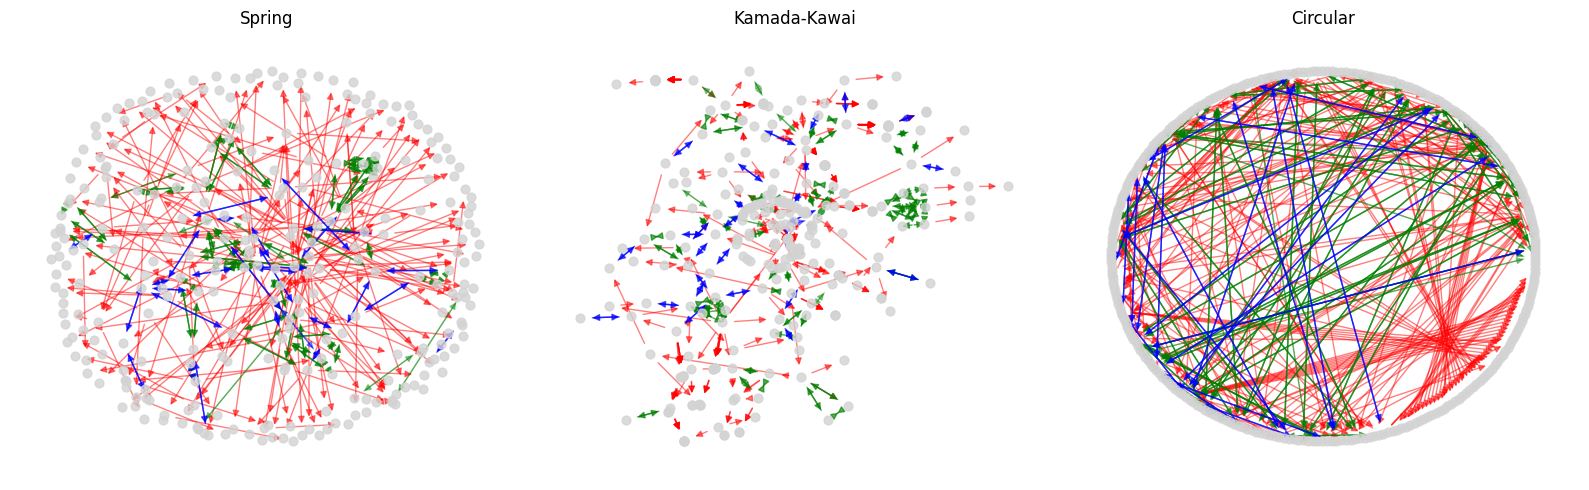

In [341]:
# === COMPARACIÓN DE LAYOUTS ===
layouts = {
    "Spring": nx.spring_layout(G, k=0.4, seed=42),
    "Kamada-Kawai": nx.kamada_kawai_layout(G),
    "Circular": nx.circular_layout(G)
}
# Creamos listas de aristas separadas por tipo para dibujarlas con distinto color
edges_killed = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "killed"]
edges_siblings = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "siblings"]
edges_married = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == "marriedEngaged"]

plt.figure(figsize=(16, 5))
for i, (name, pos_i) in enumerate(layouts.items(), 1):
    plt.subplot(1, 3, i)
    plt.title(name, fontsize=12)
    nx.draw_networkx_nodes(G, pos_i, node_size=40, node_color="lightgray", alpha=0.8)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_killed, edge_color="red", alpha=0.5)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_siblings, edge_color="green", alpha=0.4)
    nx.draw_networkx_edges(G, pos_i, edgelist=edges_married, edge_color="blue", alpha=0.4)
    plt.axis("off")
plt.tight_layout()
plt.show()


En esta celda se comparan tres layouts disponibles en NetworkX para visualizar el grafo:

- **Spring:** reparte los personajes de manera equilibrada, agrupando mejor los que están más conectados.

- **Kamada-Kawai:** ofrece una disposición algo más separada, pero menos uniforme.

- **Circular:** sitúa todos los nodos en un círculo, lo que hace más difícil distinguir las conexiones.

El objetivo aquí no es el diseño visual del grafo final, sino comprender las diferencias estructurales que cada algoritmo ofrece. Para elegir el más adecuado para la visualización principal.

**Spring layout**, basado en un modelo de fuerzas, ofrece la representación más clara y equilibrada, permitiendo identificar comunidades y relaciones sin sobrecargar la visualización.



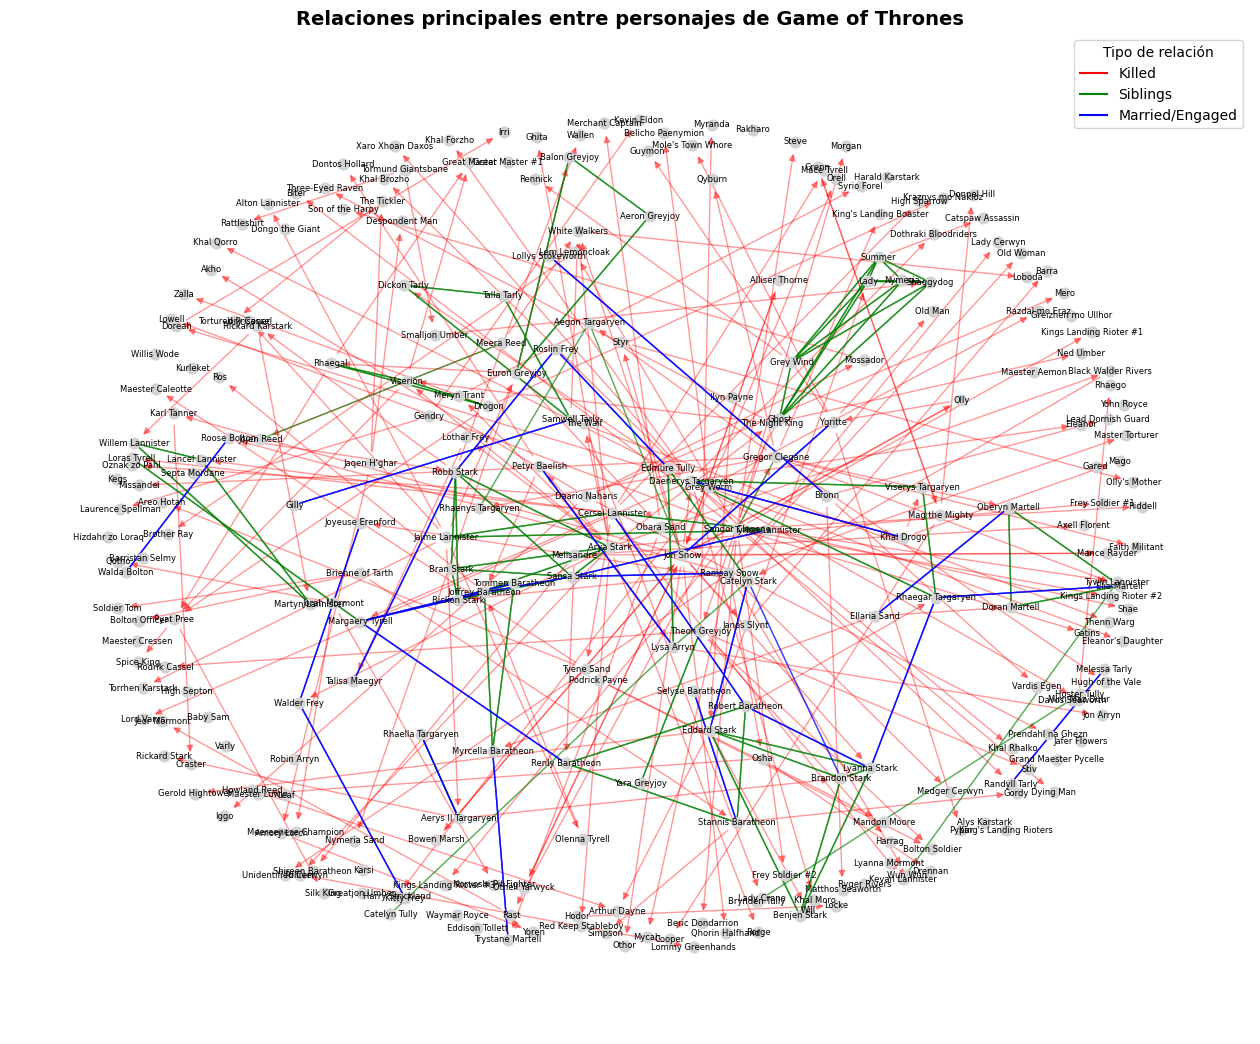

In [342]:
pos = nx.spring_layout(G, k=0.5, seed=42) 

# === VISUALIZACIÓN INICIAL DEL GRAFO ===
plt.figure(figsize=(16, 13))
plt.title("Relaciones principales entre personajes de Game of Thrones", fontsize=14, fontweight='bold')

# Dibujamos nodos 
nx.draw_networkx_nodes(G, pos, node_size=60, node_color="lightgray")

# Dibujamos aristas por tipo de relación
nx.draw_networkx_edges(G, pos, edgelist=edges_killed, edge_color="red", alpha=0.4, arrows=True)
nx.draw_networkx_edges(G, pos, edgelist=edges_siblings, edge_color="green", alpha=0.4, arrows=False)
nx.draw_networkx_edges(G, pos, edgelist=edges_married, edge_color="blue", alpha=0.5, arrows=False)

# Añadimos algunos nombres de personajes (uno de cada 35 nodos)
nx.draw_networkx_labels(G, pos, font_size=6, font_color="black")

legend_aristas = [
    plt.Line2D([], [], color='red', label='Killed'),
    plt.Line2D([], [], color='green', label='Siblings'),
    plt.Line2D([], [], color='blue', label='Married/Engaged')
]
plt.legend(handles=legend_aristas, title="Tipo de relación", loc="upper right")

plt.axis("off") #Ocultamos ejes     
plt.show()



En este primer gráfico se representa el conjunto completo de personajes y relaciones seleccionadas.

Se utiliza el layout Spring. 

El parámetro k controla la distancia media entre nodos, mientras que seed=42 asegura que la disposición sea estable entre ejecuciones.

Los nodos se muestran con tamaño uniforme para mantener una apariencia equilibrada y evitar distracciones visuales. El color azul por defecto se sustituyó por gris para resaltar mejor los distintos tipos de relaciones.

Cada tipo de relación se diferencia mediante color:

+ **Killed (rojo):** transmite conflicto, violencia y acción; es un color cálido y de alta energía que destaca las relaciones de enfrentamiento.

+ **Siblings (verde):** representa equilibrio, estabilidad y parentesco, asociado con la familia y los vínculos naturales.

+ **Married/Engaged (azul):** sugiere confianza, alianza y serenidad, apropiado para relaciones afectivas o de unión.

Las transparencias (alpha) reducen la saturación en zonas densas.

Las flechas solo se aplican a las relaciones dirigidas y las etiquetas se limitan a algunos personajes para mantener la legibilidad.

La leyenda cuadrada situada en la esquina superior derecha permite identificar rápidamente el significado de cada color.

Esta visualización proporciona una visión global de la red antes de aplicar criterios más detallados en etapas posteriores.

**5. Ajusta el tamaño de los nodos en función del número total de relaciones de cada personaje (grado).**

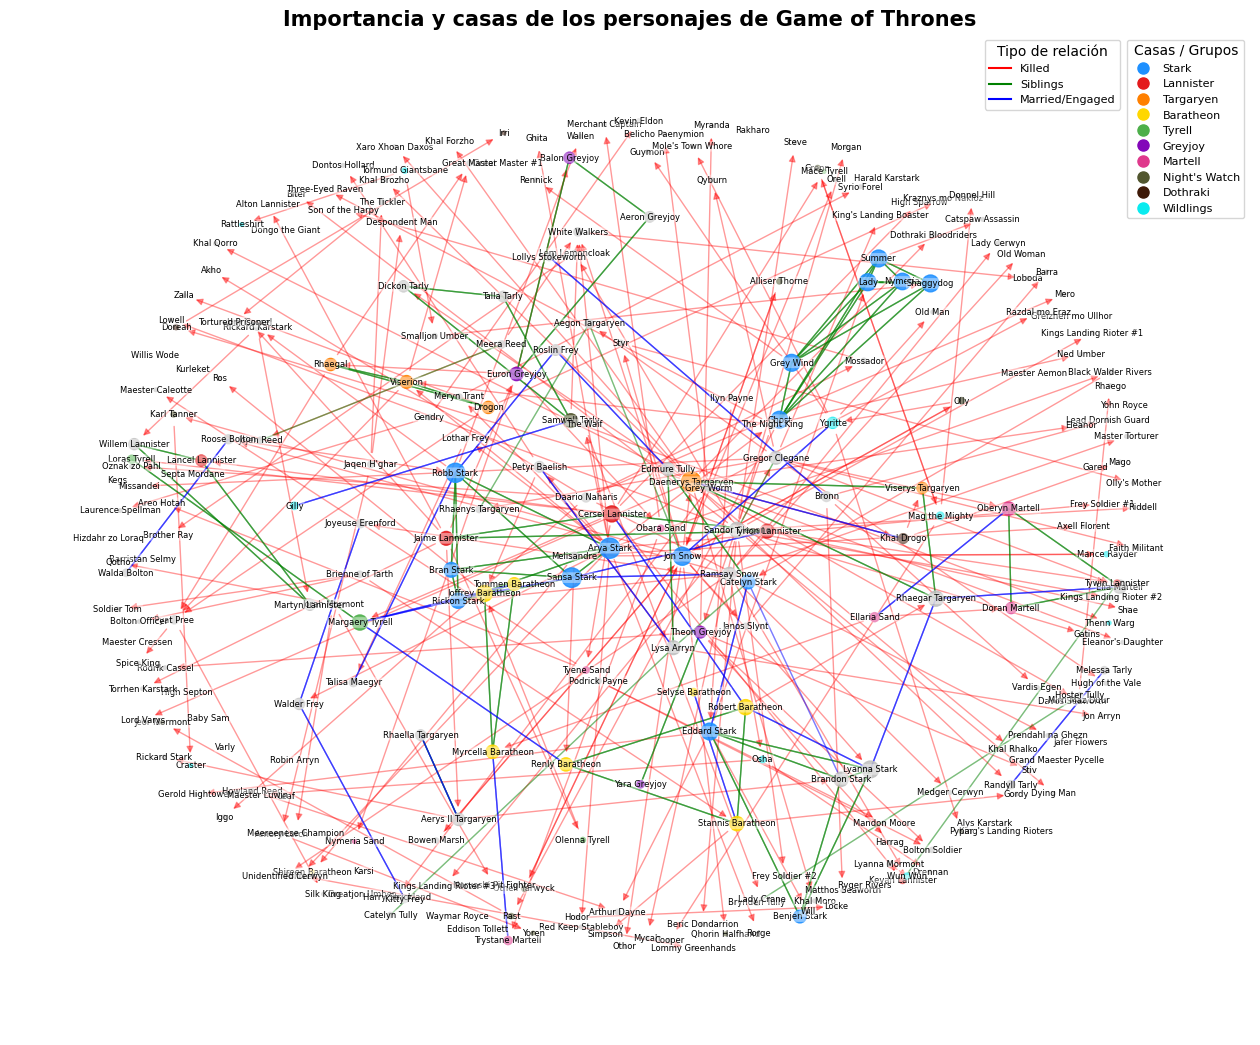

In [343]:
grados = dict(G.degree())
node_sizes = [grados[n] * 7 for n in G.nodes()]

with open(RUTA_DATA / "characters-groups.json", "r", encoding="utf-8") as f:
    grupos_data = json.load(f)["groups"]


colores = {
    "Stark": "#1E90FF", "Lannister": "#E41A1C", "Targaryen": "#FF8000",
    "Baratheon": "#FFD700", "Tyrell": "#4DAF4A", "Greyjoy": "#8306B9",
    "Martell": "#DF398C", "Night's Watch": "#51562E", "Dothraki": "#3E1907",
    "Wildlings": "#09EBEF", "Otros": "#C0C0C0"
}
color_por_personaje = {p: colores.get(g["name"], colores["Otros"])
                       for g in grupos_data for p in g["characters"]}
node_colors = [color_por_personaje.get(n, colores["Otros"]) for n in G.nodes()]

plt.figure(figsize=(16, 13))
plt.title("Importancia y casas de los personajes de Game of Thrones", fontsize=15, fontweight="bold")

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.85
)

nx.draw_networkx_edges(G, pos, edgelist=edges_killed, edge_color="red", alpha=0.4, arrows=True)
nx.draw_networkx_edges(G, pos, edgelist=edges_siblings, edge_color="green", alpha=0.3, arrows=False)
nx.draw_networkx_edges(G, pos, edgelist=edges_married, edge_color="blue", alpha=0.3, arrows=False)

nx.draw_networkx_labels(
    G, pos,
    font_size=6,
    font_color="black",
    bbox=dict(facecolor="white", alpha=0.4, edgecolor="none", boxstyle="round,pad=0.1")
)

# --- Leyenda 2: Casas / grupos ---
legend_casas = [
    plt.Line2D([], [], color=c, marker='o', linestyle='', markersize=8, label=g)
    for g, c in colores.items() if g != "Otros"
]

# --- Añadir ambas leyendas sin solaparse ---
ax = plt.gca()
legend1 = ax.legend(handles=legend_aristas, title="Tipo de relación",
                    loc="upper right", bbox_to_anchor=(0.90, 1.0), fontsize=8)
ax.add_artist(legend1)  # mantiene la primera visible

plt.legend(handles=legend_casas, title="Casas / Grupos",
           loc="upper right", bbox_to_anchor=(1.0, 1.0), fontsize=8)

plt.axis("off")
plt.show()

En este grafo se han aplicado varias mejoras respecto al anterior para resaltar la estructura e importancia de los personajes:

El tamaño de los nodos se ha ajustado en función del **grado** (número total de relaciones).

Los personajes con más conexiones aparecen más grandes, lo que facilita identificar los más influyentes en la red.

Además, se ha añadido un esquema de **colores por casa o grupo** a partir del archivo `characters-groups.json`, lo que permite identificar visualmente las alianzas y vínculos familiares más relevantes.

El resultado permite observar cómo las **casas más influyentes** (Stark, Lannister, Targaryen) concentran los nodos más grandes y las mayores interconexiones.  
En cambio, los personajes menores o aislados aparecen dispersos en los bordes del grafo, evidenciando su menor relevancia dentro de la red.

Se ha añadido una leyenda con los colores de cada casa en la esquina superior derecha para facilitar la interpretación.

Las aristas se mantienen en rojo, verde y azul para cada tipo de relación, pero con menor opacidad (alpha) para no ocultar el color de los nodos.

Las etiquetas de los personajes ahora se muestran con un fondo blanco translúcido, mejorando la legibilidad sobre los nodos de color intenso sin sobrecargar el grafo.

--- 

**Después de realizar el gráfico, responde brevemente:** 

**• ¿Qué tipo de grafo has decidido utilizar (dirigido, no dirigido o mixto)? ¿Por qué?**

Hemos utilizado un grafo mixto, ya que algunas relaciones son dirigidas (por ejemplo, killed, donde existe un emisor y un receptor) y otras no dirigidas (como siblings o married, que representan vínculos mutuos). Este enfoque permite reflejar con mayor fidelidad la naturaleza de las interacciones entre los personajes.

**• ¿Qué criterio has seguido para definir el tamaño y color de los nodos?**

El tamaño de cada nodo se ha definido en función de su grado, es decir, del número total de relaciones que mantiene cada personaje. De este modo, los personajes con más conexiones destacan visualmente.
El color de los nodos representa la casa o grupo al que pertenece cada personaje (por ejemplo, Stark, Lannister, Targaryen…), permitiendo identificar visualmente alianzas familiares o de pertenencia.

**• ¿Qué layout te ha resultado más adecuado para representar las relaciones?** 

Tras comparar varias distribuciones (spring_layout, kamada_kawai_layout y circular_layout), el layout Spring resultó el más equilibrado, ya que organiza los nodos de forma natural según sus conexiones, agrupando los personajes más relacionados en el centro y dejando los menos conectados en la periferia. Esto facilita la lectura y comprensión global de la red.

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;font-weight:bold; ">
Apartado 2: Análisis de centralidad y relevancia de personajes 
</div>

**Una vez construido el grafo, calcula diferentes medidas de centralidad para identificar los personajes más relevantes dentro de la red.** 


**1. Aplica diferentes métricas de centralidad de la librería NetworkX a cada nodo del grafo con las relaciones que has seleccionado en el apartado anterior.** 

In [344]:
# === CÁLCULO DE DIFERENTES MÉTRICAS DE CENTRALIDAD ===
centralidad_grado = nx.degree_centrality(G)
centralidad_betweenness = nx.betweenness_centrality(G)
centralidad_closeness = nx.closeness_centrality(G)

**2. Haz una visualización por cada métrica donde se muestre los 10 personajes más importantes según cada una de ellas. Aquí se debe observar al menos el nombre del personaje y el valor de la métrica.** 

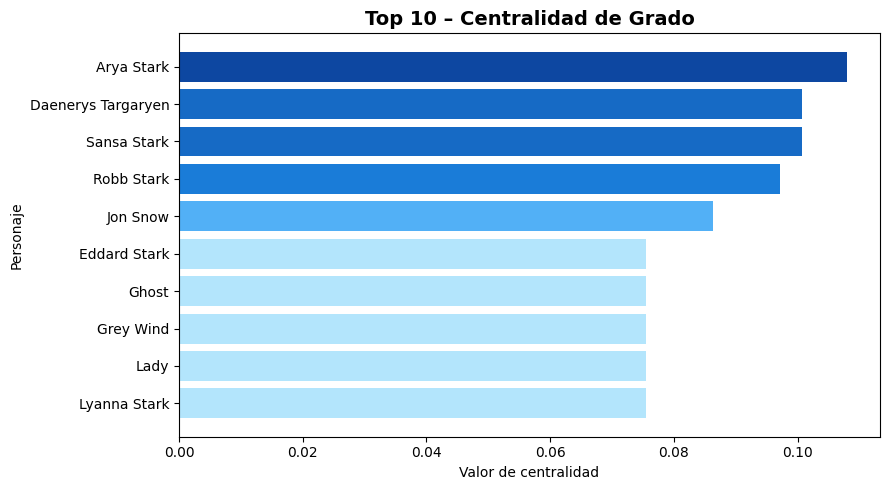

Posición,Personaje,Valor de centralidad de grado
1,Arya Stark,0.107900
2,Daenerys Targaryen,0.100700
3,Sansa Stark,0.100700
4,Robb Stark,0.097100
5,Jon Snow,0.086300
6,Eddard Stark,0.075500
7,Ghost,0.075500
8,Grey Wind,0.075500
9,Lady,0.075500
10,Lyanna Stark,0.075500


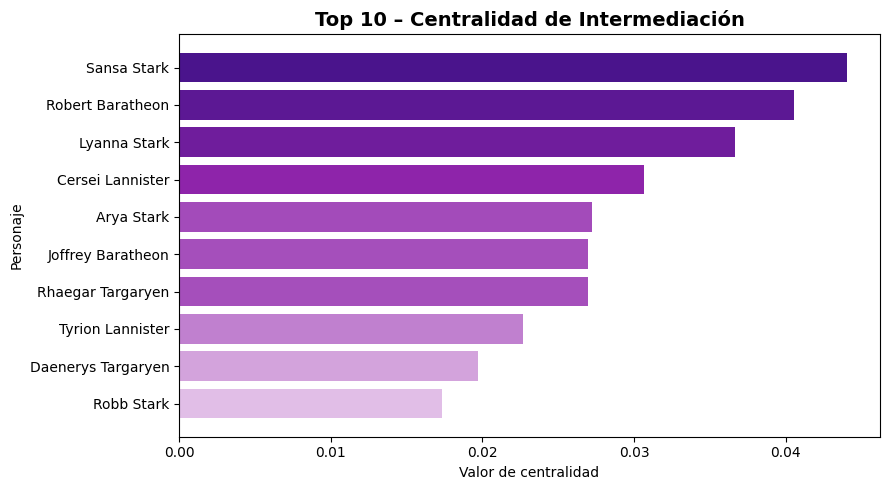

Posición,Personaje,Valor de centralidad de intermediación
1,Sansa Stark,0.044000
2,Robert Baratheon,0.040500
3,Lyanna Stark,0.036600
4,Cersei Lannister,0.030700
5,Arya Stark,0.027200
6,Joffrey Baratheon,0.027000
7,Rhaegar Targaryen,0.027000
8,Tyrion Lannister,0.022700
9,Daenerys Targaryen,0.019700
10,Robb Stark,0.017300


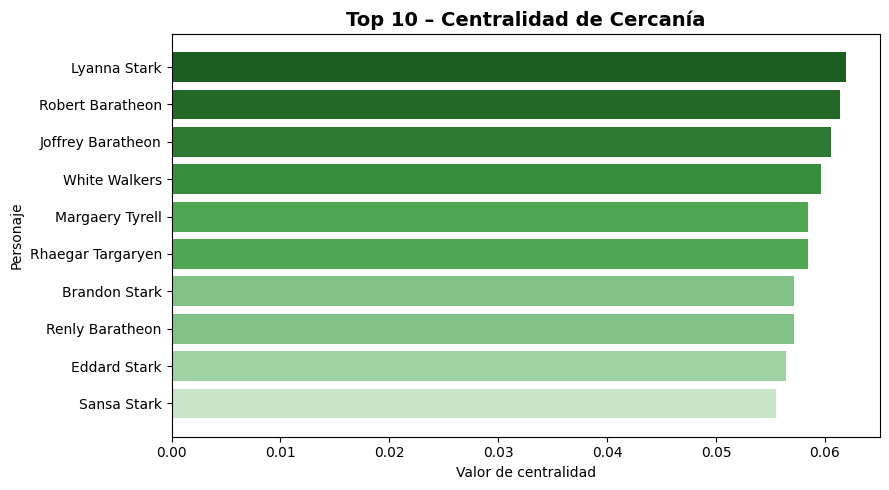

Posición,Personaje,Valor de centralidad de cercanía
1,Lyanna Stark,0.062000
2,Robert Baratheon,0.061400
3,Joffrey Baratheon,0.060600
4,White Walkers,0.059600
5,Margaery Tyrell,0.058400
6,Rhaegar Targaryen,0.058400
7,Brandon Stark,0.057200
8,Renly Baratheon,0.057200
9,Eddard Stark,0.056500
10,Sansa Stark,0.055500


In [345]:
# --- Paletas distintas por métrica ---
paletas = {
    "grado": LinearSegmentedColormap.from_list("azules", ["#B3E5FC", "#2196F3", "#0D47A1"], N=256),
    "betweenness": LinearSegmentedColormap.from_list("purpura", ["#E1BEE7", "#8E24AA", "#4A148C"], N=256),
    "closeness": LinearSegmentedColormap.from_list("verde", ["#C8E6C9", "#43A047", "#1B5E20"], N=256)
}

# --- Función general ---
def graficar_top10(metrica, titulo, nombre_metrica, cmap):
    top10 = sorted(metrica.items(), key=lambda x: x[1], reverse=True)[:10]
    nombres = [n for n, _ in top10]
    valores = [v for _, v in top10]
    norm_vals = (valores - np.min(valores)) / (np.max(valores) - np.min(valores))
    colores = [cmap(v) for v in norm_vals]

    plt.figure(figsize=(9, 5))
    plt.title(titulo, fontsize=14, fontweight="bold")
    plt.barh(nombres[::-1], valores[::-1], color=colores[::-1])
    plt.xlabel("Valor de centralidad", fontsize=10)
    plt.ylabel("Personaje", fontsize=10)
    plt.tight_layout()
    plt.show()

    df = pd.DataFrame({
        "Posición": range(1, 11),
        "Personaje": nombres,
        f"Valor de {nombre_metrica}": np.round(valores, 4)
    })
    display(df.style.hide(axis="index"))

# --- Visualizaciones ---
graficar_top10(centralidad_grado, "Top 10 – Centralidad de Grado", "centralidad de grado", paletas["grado"])
graficar_top10(centralidad_betweenness, "Top 10 – Centralidad de Intermediación", "centralidad de intermediación", paletas["betweenness"])
graficar_top10(centralidad_closeness, "Top 10 – Centralidad de Cercanía", "centralidad de cercanía", paletas["closeness"])


**Justificación de diseño**

Para la representación de los Top 10 personajes en cada métrica de centralidad se han aplicado criterios de diseño:

+ Se ha utilizado un color degradado distinto para cada métrica (azul para grado, púrpura para intermediación y verde para cercanía*), con el objetivo de diferenciar visualmente los tres tipos de importancia.

    Cada degradado va de claro a oscuro, donde el tono más oscuro representa el personaje con mayor valor de centralidad.
Se ha intentado que los degradados sean lo más distintos posible, aunque al tratarse de métricas de naturaleza similar, algunos tonos pueden parecer cercanos.

+ Las barras se han dispuesto de forma horizontal, ordenadas de mayor a menor, lo que facilita la comparación inmediata de los valores entre personajes y reduce la carga visual frente a un gráfico vertical.

+ Cada barra se muestra completamente coloreada, sin bordes negros ni contornos, para mantener un estilo limpio y uniforme, priorizando la lectura del color como indicador principal de relevancia.

+ Los títulos se presentan en negrita para reforzar la jerarquía visual entre las tres métricas, mientras que se ha optado por eliminar la cuadrícula (grid) y otros elementos secundarios del gráfico, buscando una presentación más clara y equilibrada.

+ Además, junto a cada gráfico se incluye una tabla con los valores exactos de centralidad.
Esto permite complementar la lectura visual con los datos numéricos, facilitando una interpretación más precisa y coherente con el análisis comparativo posterior. 



**3. Realiza una nueva visualización en la que el tamaño del nodo represente la importancia del personaje según la métrica que consideras que muestra mejor los personajes más importantes de la historia.** 

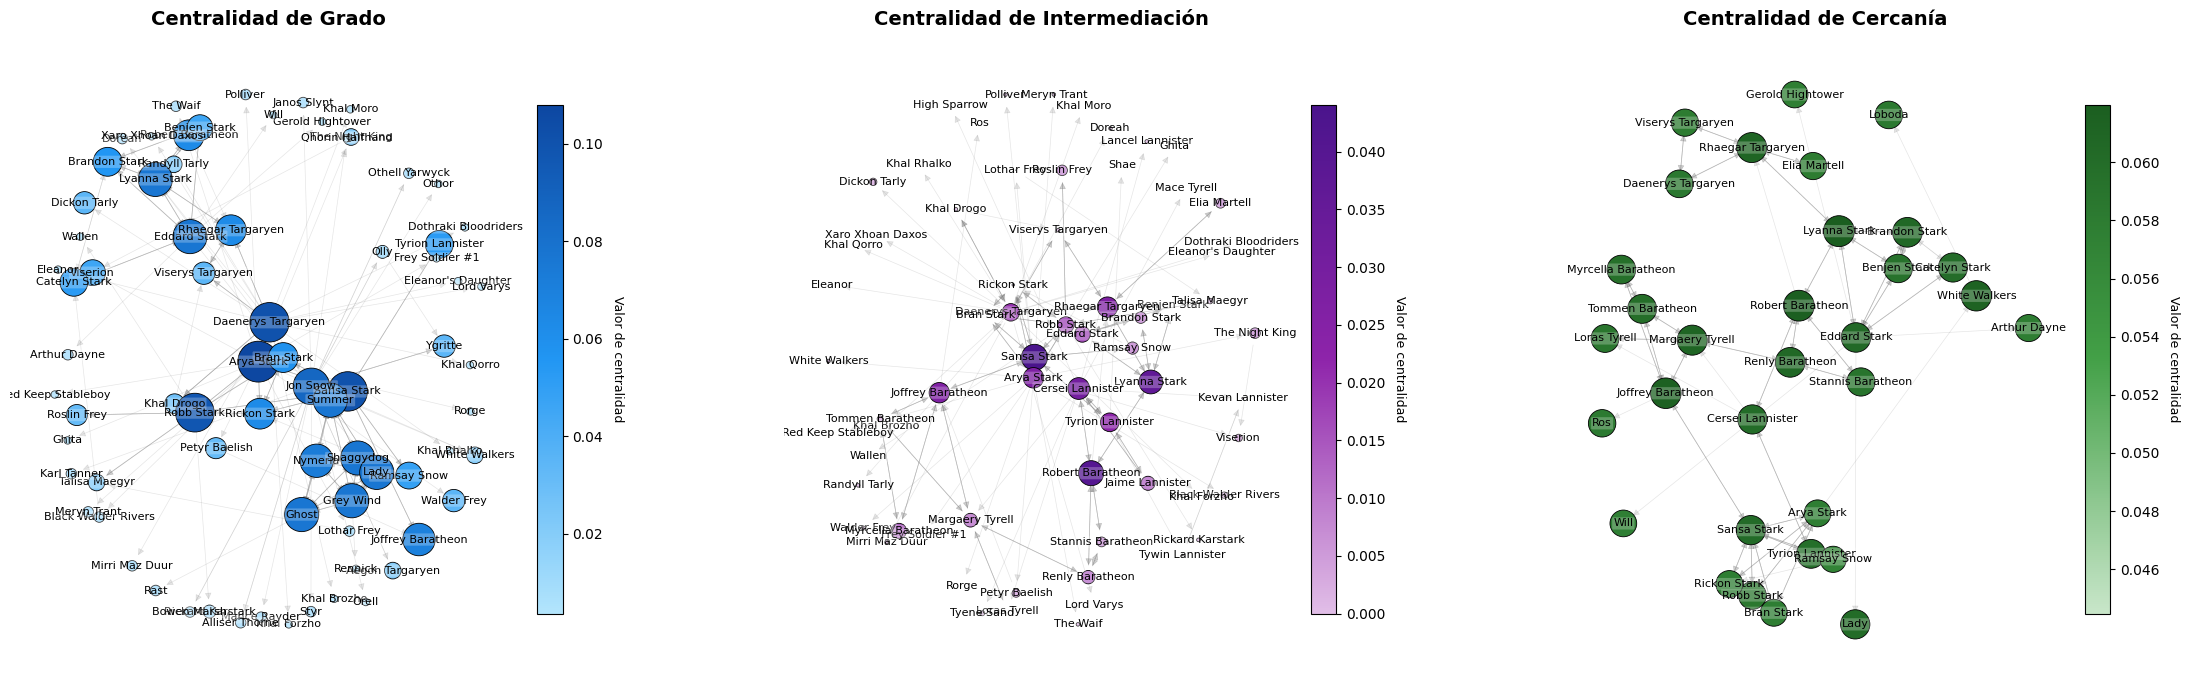

In [346]:
metricas = {
    "Centralidad de Grado": (centralidad_grado, paletas["grado"]),
    "Centralidad de Intermediación": (centralidad_betweenness, paletas["betweenness"]),
    "Centralidad de Cercanía": (centralidad_closeness, paletas["closeness"])
}

# Crear figura horizontal con tres subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
plt.subplots_adjust(wspace=0.15)

for ax, (titulo, (centralidad, cmap)) in zip(axes, metricas.items()):
    # Top 10 + vecinos
    top10 = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:10]
    top_nodes = [n for n, _ in top10]

    nodos_relacionados = set(top_nodes)
    for n in top_nodes:
        nodos_relacionados.update(G.neighbors(n))
    subG = G.subgraph(nodos_relacionados)

    # Layout y normalización
    pos_sub = nx.spring_layout(subG, k=0.8, seed=42)
    valores_nodos = [centralidad.get(n, 0) for n in subG.nodes()]
    max_val = max(valores_nodos) if max(valores_nodos) > 0 else 1
    colores = cmap([v / max_val for v in valores_nodos])
    tamaños = [8000 * v for v in valores_nodos]

    # Aristas
    nx.draw_networkx_edges(subG, pos_sub, alpha=0.2, edge_color="gray", arrows=True, width=0.5, ax=ax)

    # Nodos
    nx.draw_networkx_nodes(
        subG, pos_sub,
        node_color=colores,
        node_size=tamaños,
        edgecolors="black",
        linewidths=0.6,
        ax=ax
    )

    # Etiquetas
    nx.draw_networkx_labels(
        subG, pos_sub,
        font_size=8,
        font_color="black",
        bbox=dict(facecolor="white", alpha=0.25, edgecolor="none", boxstyle="round,pad=0.1"),
        ax=ax
    )

    # Título y barra de color
    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=10)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(valores_nodos), vmax=max_val))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("Valor de centralidad", rotation=270, labelpad=15, fontsize=9)

    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)

plt.show()

Aunque se han representado las tres métricas, las que mejor reflejan a los personajes más importantes de la historia son la centralidad de grado y la centralidad de intermediación.
La centralidad de grado permite identificar a los personajes con más conexiones directas dentro de la red —como Arya, Sansa o Jon Snow—, lo que resulta especialmente relevante dado que las relaciones seleccionadas (familiares y de conflicto) generan una estructura muy densa entre miembros de las mismas casas.

Por otro lado, la centralidad de intermediación destaca a personajes como Sansa Stark, Robert Baratheon o Cersei Lannister, que actúan como puentes entre distintas casas y tramas, mostrando su importancia en la conexión de distintos grupos dentro de la historia.

En conjunto, ambas métricas aportan perspectivas complementarias: la de grado resalta la influencia local, mientras que la de intermediación refleja la relevancia estructural. En este grafo, ambas ofrecen una visión coherente de los personajes clave de Game of Thrones.<br><br>

**Justificación de diseño**

En esta visualización se han representado las tres métricas de centralidad (grado, intermediación y cercanía) mediante grafos con **mapa de calor**, utilizando la misma paleta de colores que en las gráficas anteriores para mantener coherencia visual y facilitar la interpretación. 

Aunque el enunciado solo requería representar la importancia de los personajes mediante el tamaño de los nodos, se ha decidido complementar este criterio con un **mapa de calor** para **reforzar visualmente las diferencias de centralidad** entre personajes.
El color añade una segunda dimensión de información, permitiendo identificar de un vistazo quiénes destacan más dentro de cada red sin depender únicamente del tamaño.

Esta decisión busca ofrecer una visualización **más informativa y comparativa**, permitiendo analizar no solo la posición de los personajes más relevantes, sino también cómo varía su nivel de centralidad relativa dentro de cada métrica.

Se ha optado por mostrar **únicamente los 10 personajes más relevantes** según cada métrica, junto con sus **vecinos directos**, dado que el objetivo del apartado es analizar la **relevancia dentro de la red** más que su estructura global. Incluir todos los nodos habría sobrecargado la visualización y dificultado la interpretación de las diferencias entre métricas. Llevan un fondo en blanco con un alpha muy bajo para que se vea bien el color del nodo.

Los tonos más oscuros representan a los personajes más influyentes según la medida correspondiente.

Los nodos conservan un **tamaño proporcional al valor de centralidad**, y se han añadido **bordes negros** para asegurar contraste con el fondo y la escala de color.

Por último, se ha elegido un diseño **en formato horizontal (1×3)** que permite comparar fácilmente las tres métricas en una misma figura sin necesidad de desplazarse por el notebook. Esta disposición facilita observar, de un vistazo, cómo cambian las zonas centrales de la red según el criterio de análisis empleado.

En conjunto, el diseño proporciona una representación **limpia, coherente con las figuras anteriores** y centrada en el propósito del apartado: **identificar y comparar los personajes más relevantes dentro de la red de relaciones seleccionada.** <br><br>


**Después de realizar el gráfico, responde brevemente:**


**¿Qué diferencias observas entre las distintas medidas de centralidad?**

Cada métrica pone el foco en un tipo diferente de relevancia dentro de la red.

+ La **centralidad de grado** mide la cantidad de conexiones directas y resalta la popularidad local de los personajes.

+ La **centralidad de intermediación** identifica a quienes actúan como puentes entre grupos o casas, revelando su capacidad de conexión entre distintas partes de la red.

+ La **centralidad de cercanía**, en cambio, refleja qué tan cerca está cada personaje del resto, destacando a los que pueden llegar más rápidamente al conjunto de la red.

En conjunto, las tres ofrecen perspectivas complementarias: la de grado muestra influencia inmediata, la de intermediación la posición estructural, y la de cercanía la accesibilidad general. <br><br>



**¿Los personajes más “centrales” coinciden con los más importantes en la historia?**

En parte sí. Los personajes Stark —como Arya, Sansa o Jon Snow— aparecen entre los más centrales, lo que coincide con su protagonismo narrativo.

Sin embargo, al no incluir relaciones como *parents* o *allies*, algunos personajes clave a nivel estratégico (como Tyrion Lannister o Daenerys Targaryen) no destacan tanto en las métricas, ya que su importancia no se basa tanto en la cantidad de relaciones directas, sino en su papel político o narrativo dentro de la historia.<br><br>



**¿Cómo influye la forma de calcular la centralidad en la interpretación del grafo?**

La elección de las relaciones y de la métrica modifica radicalmente el resultado.

Al centrarse en **killed**, **married** y **siblings**, el grafo prioriza los **vínculos familiares y de conflicto**, generando redes más cerradas donde los Stark y los Baratheon son los más centrales.

Si se añadieran relaciones de **parentesco o alianza**, la estructura se abriría y destacarían personajes más estratégicos o mediadores entre tramas.

Por tanto, **la forma de calcular la centralidad determina qué tipo de “importancia” estamos midiendo**: social, estructural o narrativa. <br><br>



<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px; font-weight:bold;">
Apartado 3: Subredes y comunidades  
</div>

**En este apartado se explorará la estructura interna de la red mediante el análisis de subgrupos de personajes.** 

**1. Crea subgrafos a partir de uno o varios tipos de relación (por ejemplo, solo relaciones familiares o solo relaciones de conflicto).** 

Subgrafo familiar → Nodos: 82 | Aristas: 98
Subgrafo conflicto → Nodos: 229 | Aristas: 211


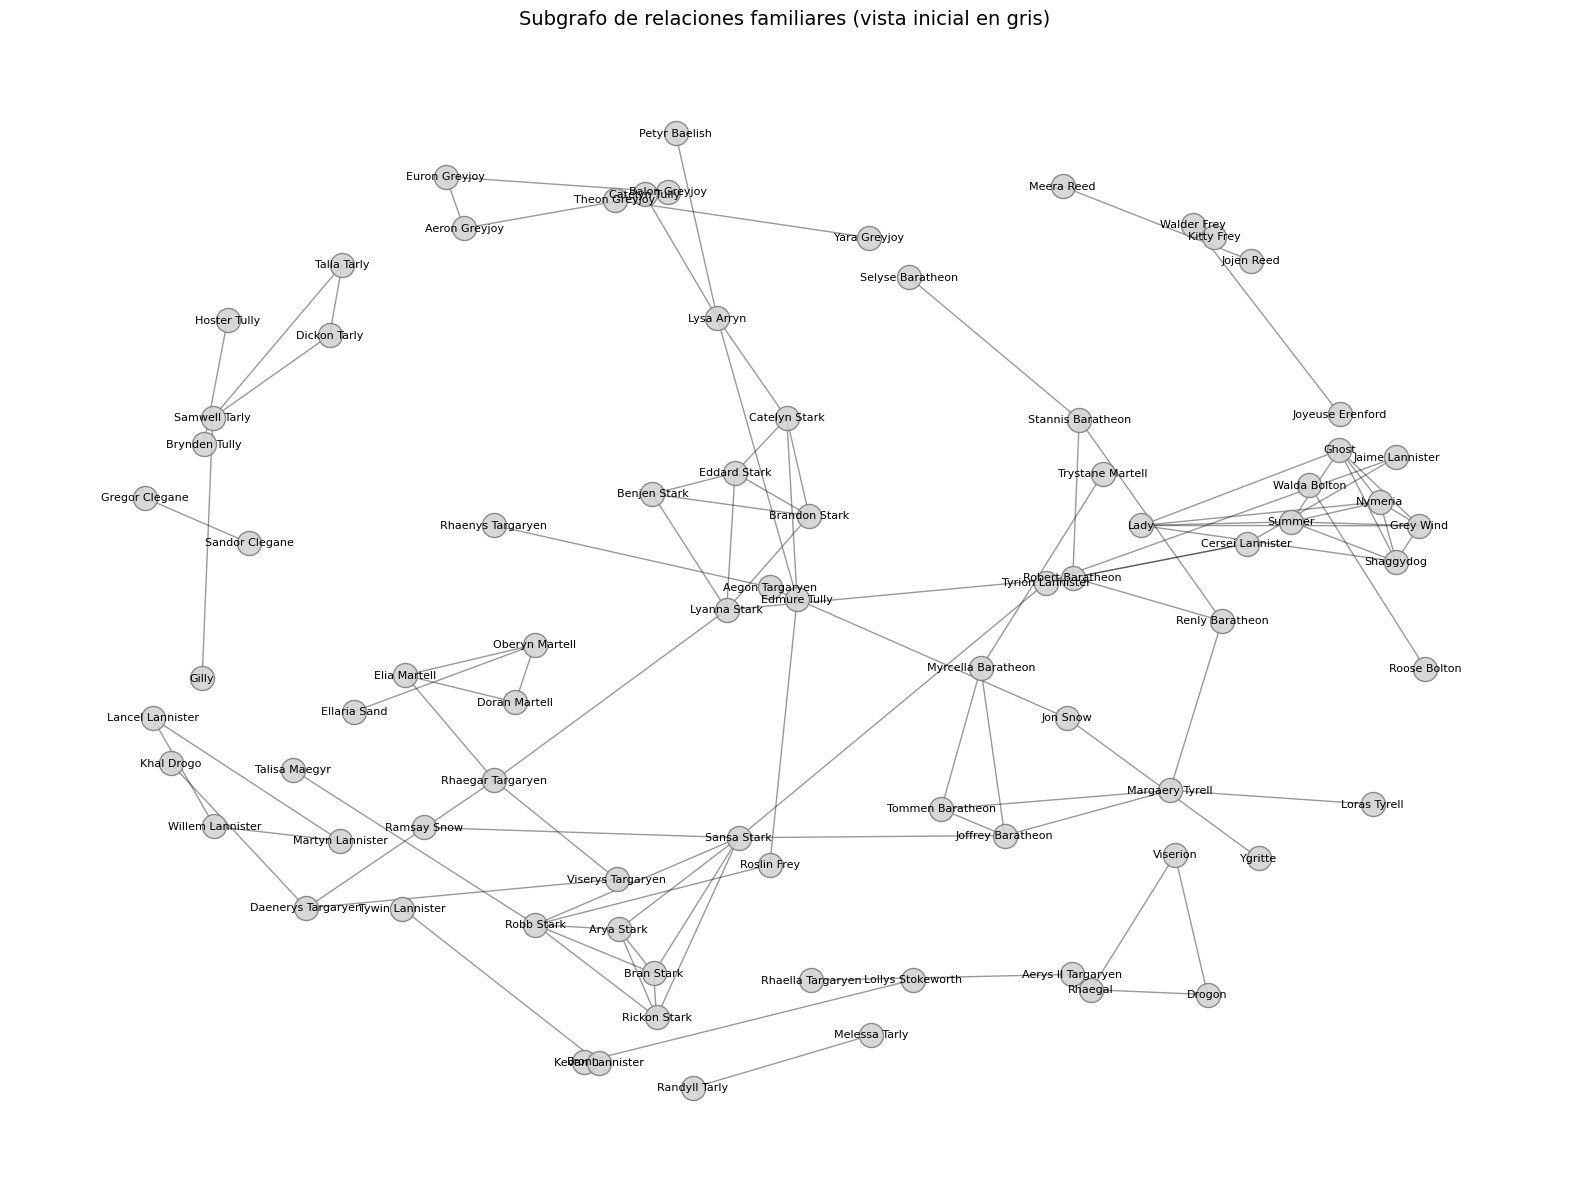

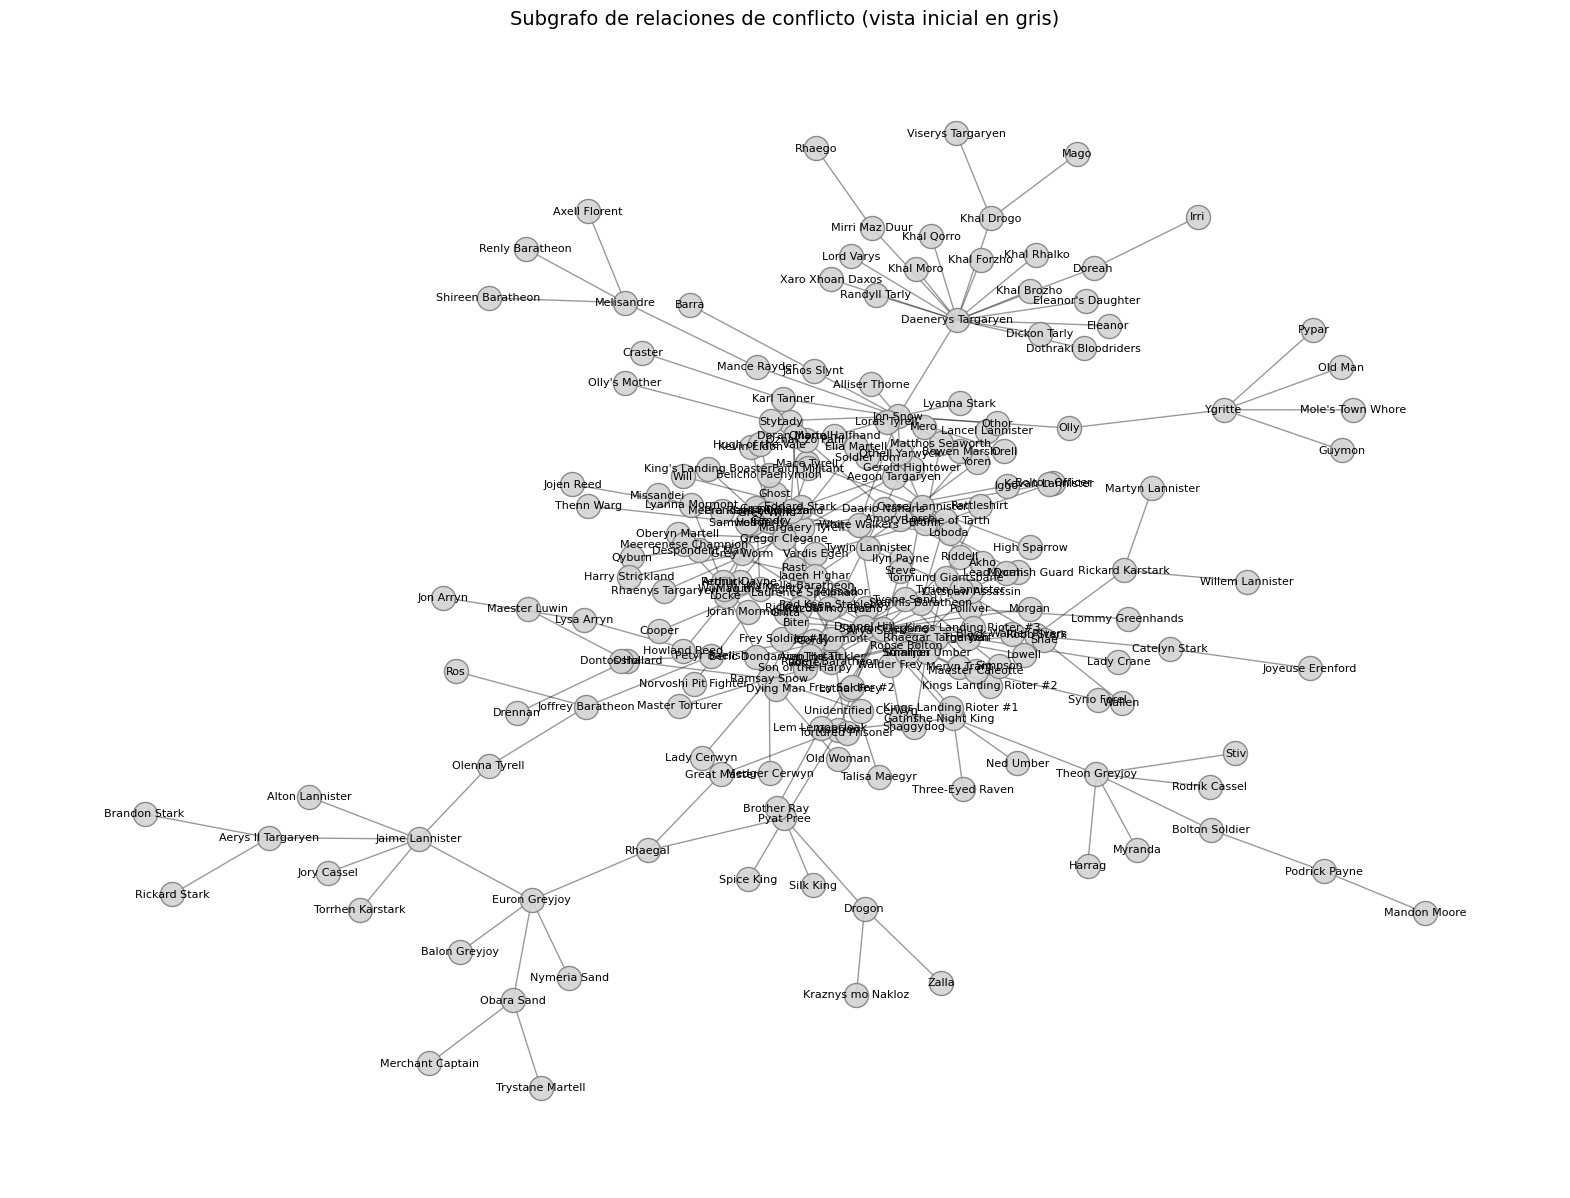

In [347]:
def crear_subgrafo(G, relaciones):
    """Filtra las aristas del grafo según el tipo de relación y devuelve un subgrafo no dirigido."""
    edges = [(u, v, d) for u, v, d in G.edges(data=True) if d["relation"] in relaciones]
    G_sub = nx.Graph()
    G_sub.add_edges_from(edges)
    return G_sub

def visualizar_subgrafo(G_sub, pos, titulo, node_colors=None):
    """Visualiza un subgrafo con colores opcionales (por defecto en gris)."""
    plt.figure(figsize=(20, 15))
    if node_colors is None:
        node_colors = "lightgray" 
    nx.draw_networkx_nodes(G_sub, pos, node_size=300, node_color=node_colors, alpha=0.9, edgecolors="gray")
    nx.draw_networkx_edges(G_sub, pos, alpha=0.4)
    nx.draw_networkx_labels(G_sub, pos, font_size=8)
    plt.title(titulo, fontsize=14)
    plt.axis("off")
    plt.show()

# --- Definición de relaciones ---
relaciones_familia = {"siblings", "parents", "sibling", "parentOf", "marriedEngaged"}
relaciones_conflicto = {"killed", "killedBy"}

# --- Creación de subgrafos ---
G_familia = crear_subgrafo(G, relaciones_familia)
G_conflicto = crear_subgrafo(G, relaciones_conflicto)

# --- Estadísticas ---
print(f"Subgrafo familiar → Nodos: {G_familia.number_of_nodes()} | Aristas: {G_familia.number_of_edges()}")
print(f"Subgrafo conflicto → Nodos: {G_conflicto.number_of_nodes()} | Aristas: {G_conflicto.number_of_edges()}")

# --- Visualización inicial en gris ---
pos_familia = nx.spring_layout(G_familia, k=0.5, seed=42)
pos_conflicto = nx.kamada_kawai_layout(G_conflicto, scale=500)

visualizar_subgrafo(G_familia, pos_familia, "Subgrafo de relaciones familiares (vista inicial en gris)")
visualizar_subgrafo(G_conflicto, pos_conflicto, "Subgrafo de relaciones de conflicto (vista inicial en gris)")


En esta primera parte se crean dos subgrafos a partir del grafo general:
uno centrado en las relaciones familiares (siblings, parents, marriedEngaged) y otro en las relaciones de conflicto (killed, killedBy).
Se ha optado por un grafo no dirigido (nx.Graph) en lugar de un MultiDiGraph, ya que en este contexto el interés está en analizar la estructura de conexión entre personajes, sin priorizar la dirección de las relaciones.

Aunque el enunciado solo exige la creación de los subgrafos, se decidió incluir una visualización inicial en gris para facilitar la comparación con las versiones coloreadas y con tamaños proporcionales que se mostrarán en los siguientes apartados.

**2. Aplica un algoritmo de detección de comunidades de las que ofrece la librería NetworkX para identificar grupos dentro de la red.**

In [348]:
from networkx.algorithms.community import greedy_modularity_communities

def detectar_comunidades(G_sub):
    """Detecta comunidades en un subgrafo y añade el atributo 'comunidad' a cada nodo."""
    comunidades = list(greedy_modularity_communities(G_sub))
    comunidad_dict = {nodo: i for i, c in enumerate(comunidades) for nodo in c}
    nx.set_node_attributes(G_sub, comunidad_dict, "comunidad")
    return comunidades, comunidad_dict

# --- Detección en ambos subgrafos ---
comunidades_familia, comunidad_dict_familia = detectar_comunidades(G_familia)
comunidades_conflicto, comunidad_dict_conflicto = detectar_comunidades(G_conflicto)

#--- Resultados ---
print(f"Comunidades detectadas (familia): {len(comunidades_familia)}")
print(f"Comunidades detectadas (conflicto): {len(comunidades_conflicto)}")



Comunidades detectadas (familia): 21
Comunidades detectadas (conflicto): 29


A cada subgrafo se le ha aplicado el algoritmo Greedy Modularity, que agrupa los nodos en función de su densidad de conexiones internas.
Este método es apropiado para redes sociales como Game of Thrones, donde las comunidades suelen corresponder con familias o alianzas políticas.
Se ha asignado a cada personaje un identificador de comunidad que se utilizará después para colorear los nodos.

**3. Realiza una visualización en la que cada comunidad aparezca con un color diferente.** 


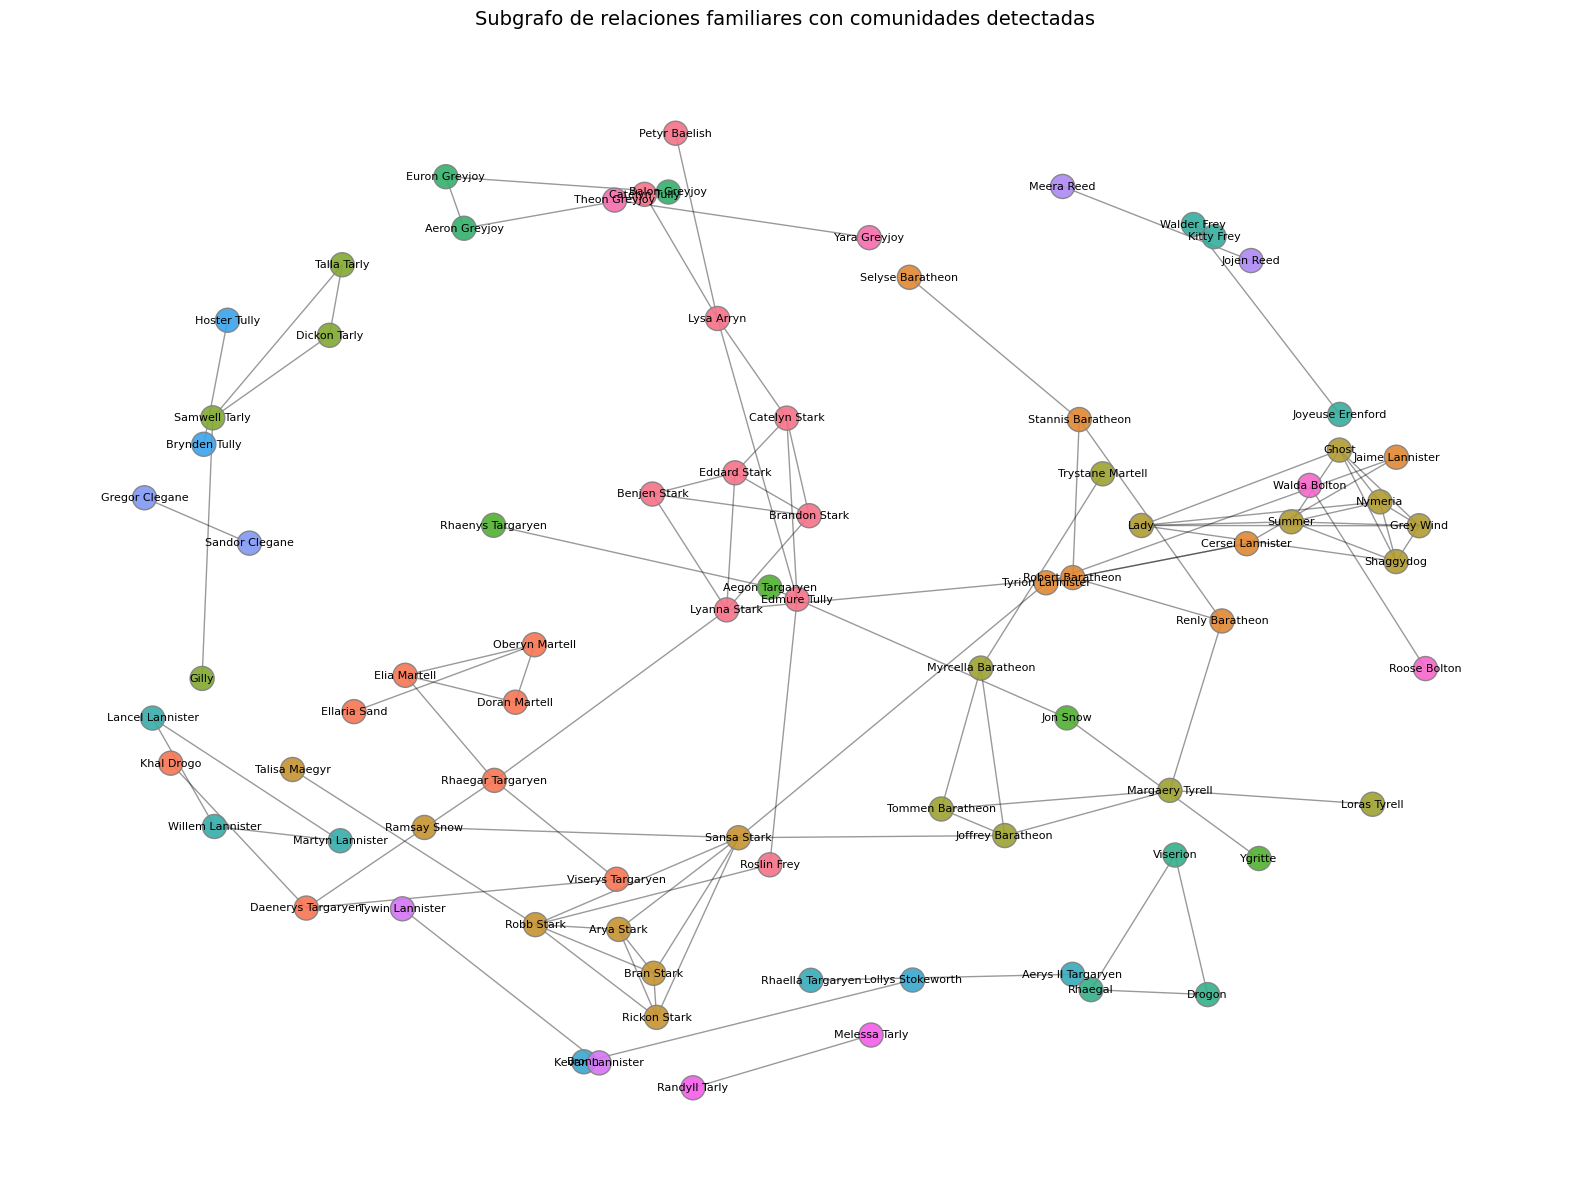

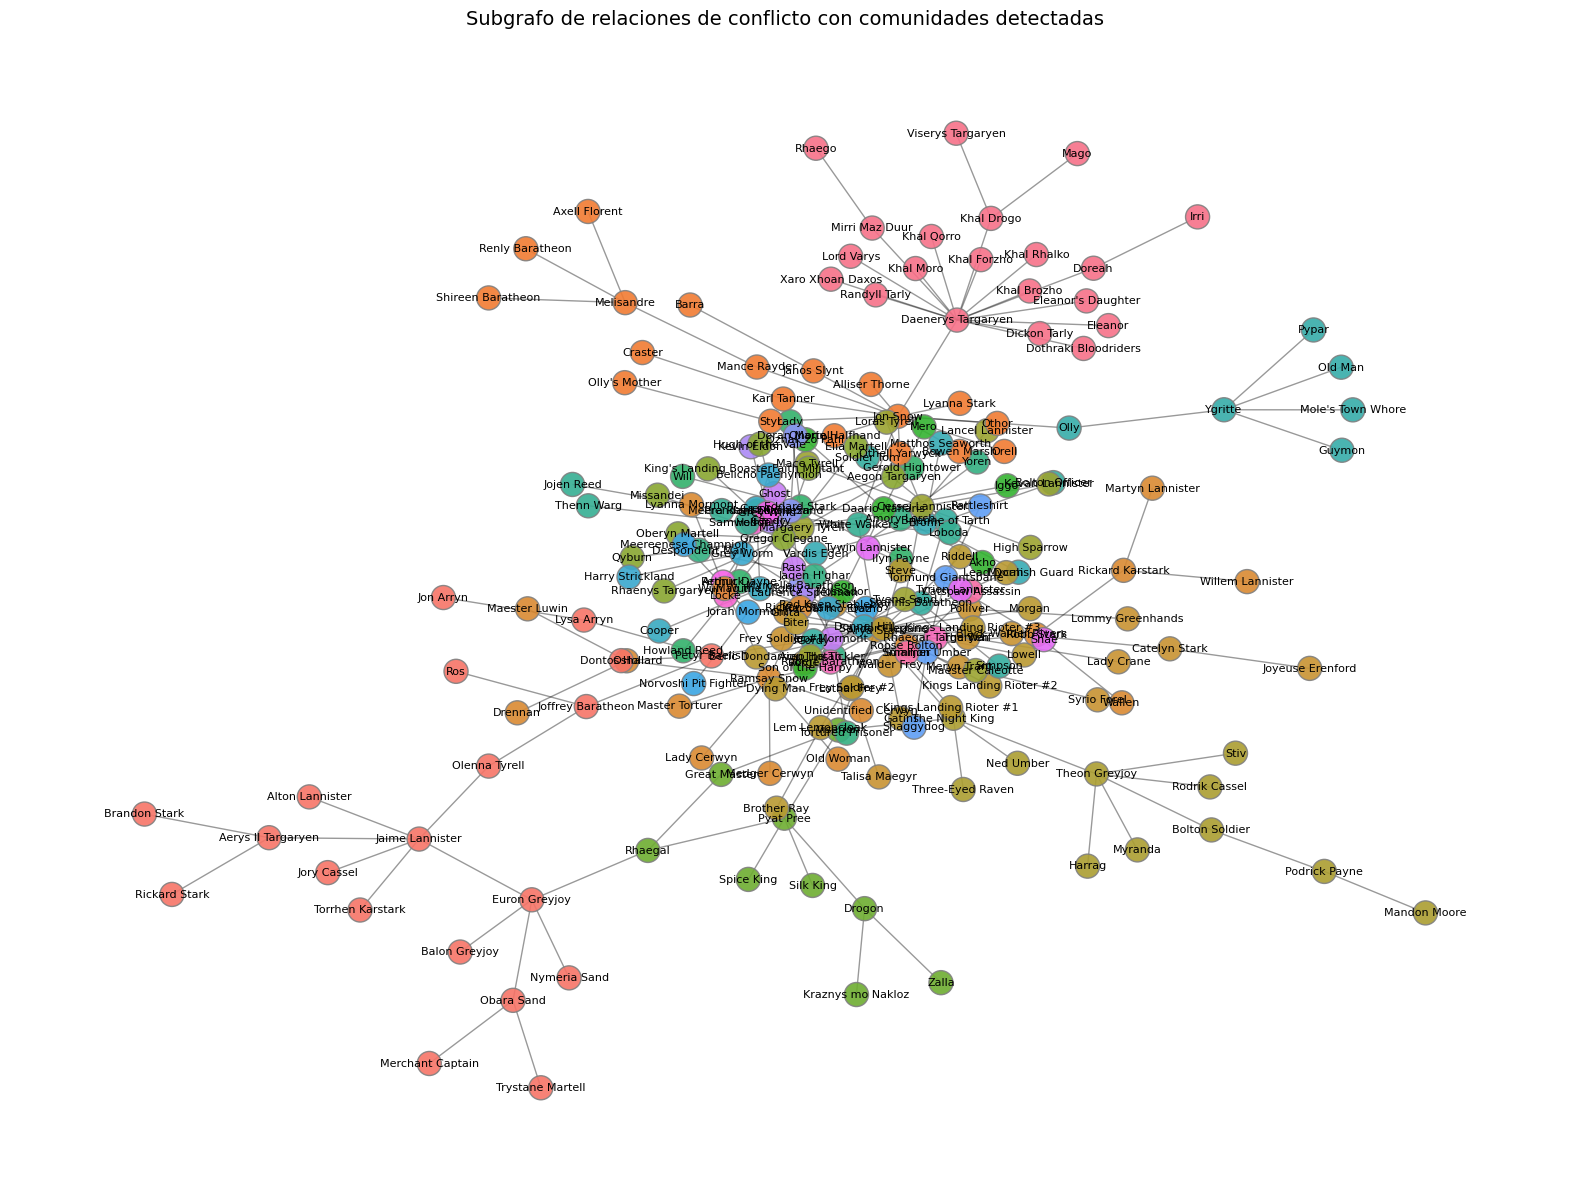

In [349]:
# --- Paletas de color según número de comunidades ---
colores_fam = sns.color_palette("husl", len(comunidades_familia))
colores_con = sns.color_palette("husl", len(comunidades_conflicto))

# --- Colores asignados por comunidad ---
node_colors_fam = [colores_fam[comunidad_dict_familia.get(n, 0)] for n in G_familia.nodes()]
node_colors_con = [colores_con[comunidad_dict_conflicto.get(n, 0)] for n in G_conflicto.nodes()]

# --- Visualización con colores por comunidad ---
visualizar_subgrafo(G_familia, pos_familia, "Subgrafo de relaciones familiares con comunidades detectadas", node_colors=node_colors_fam)

visualizar_subgrafo(G_conflicto, pos_conflicto, "Subgrafo de relaciones de conflicto con comunidades detectadas", node_colors=node_colors_con)

**4. Ajusta el tamaño de los nodos según su número de relaciones dentro de la comunidad seleccionada.**


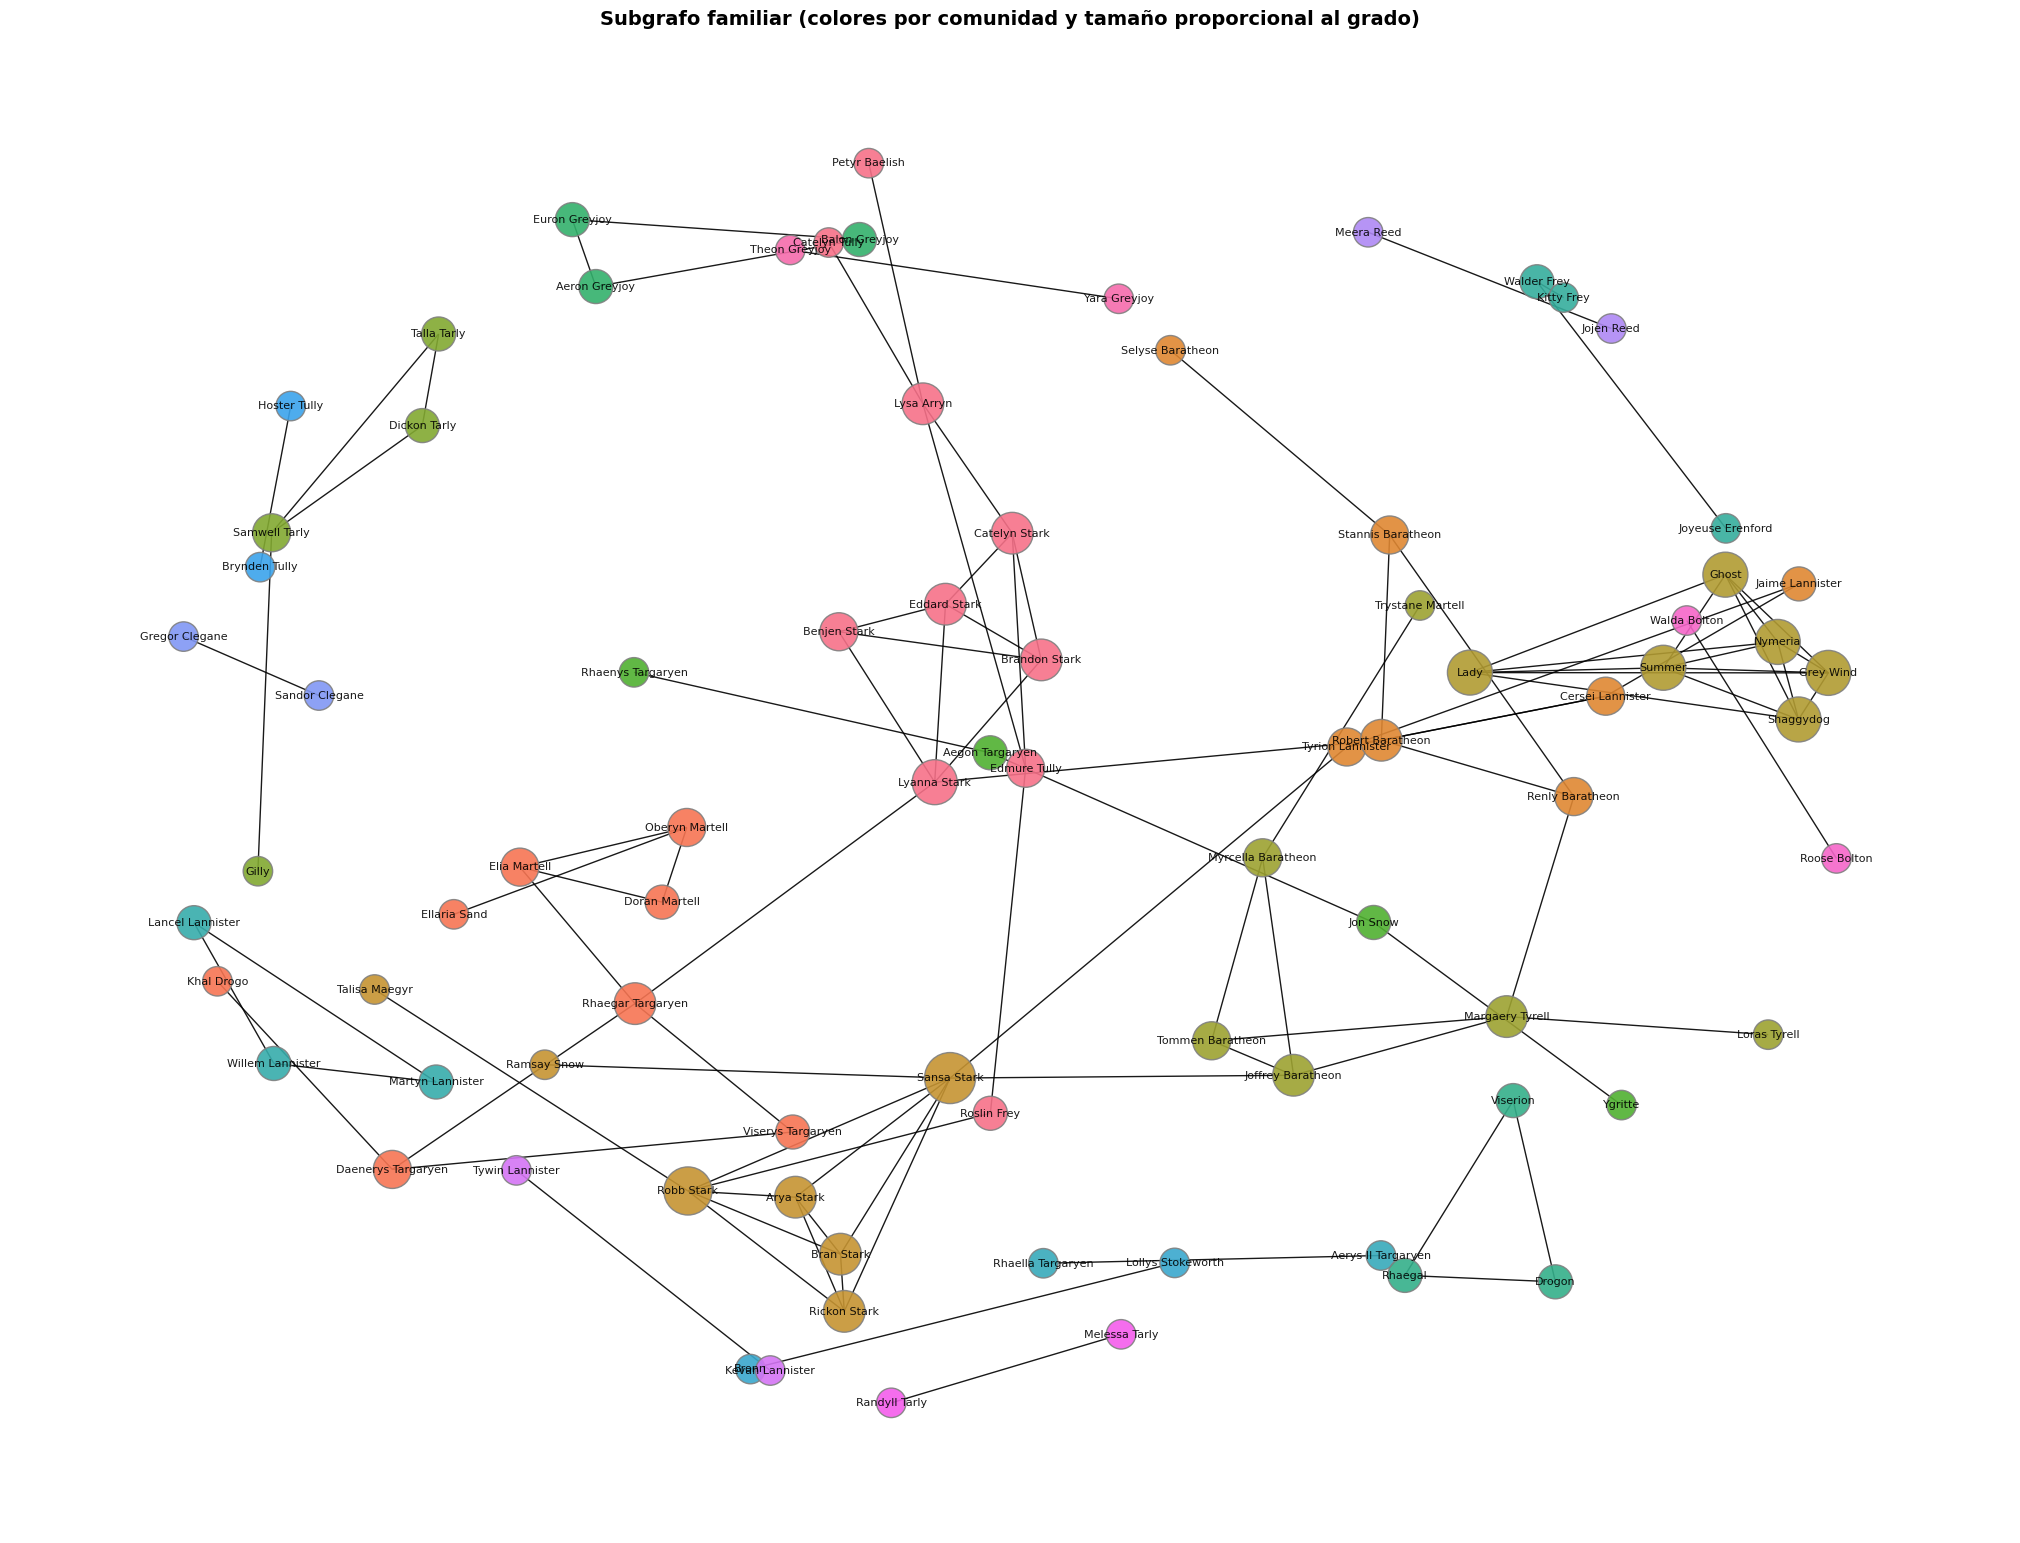

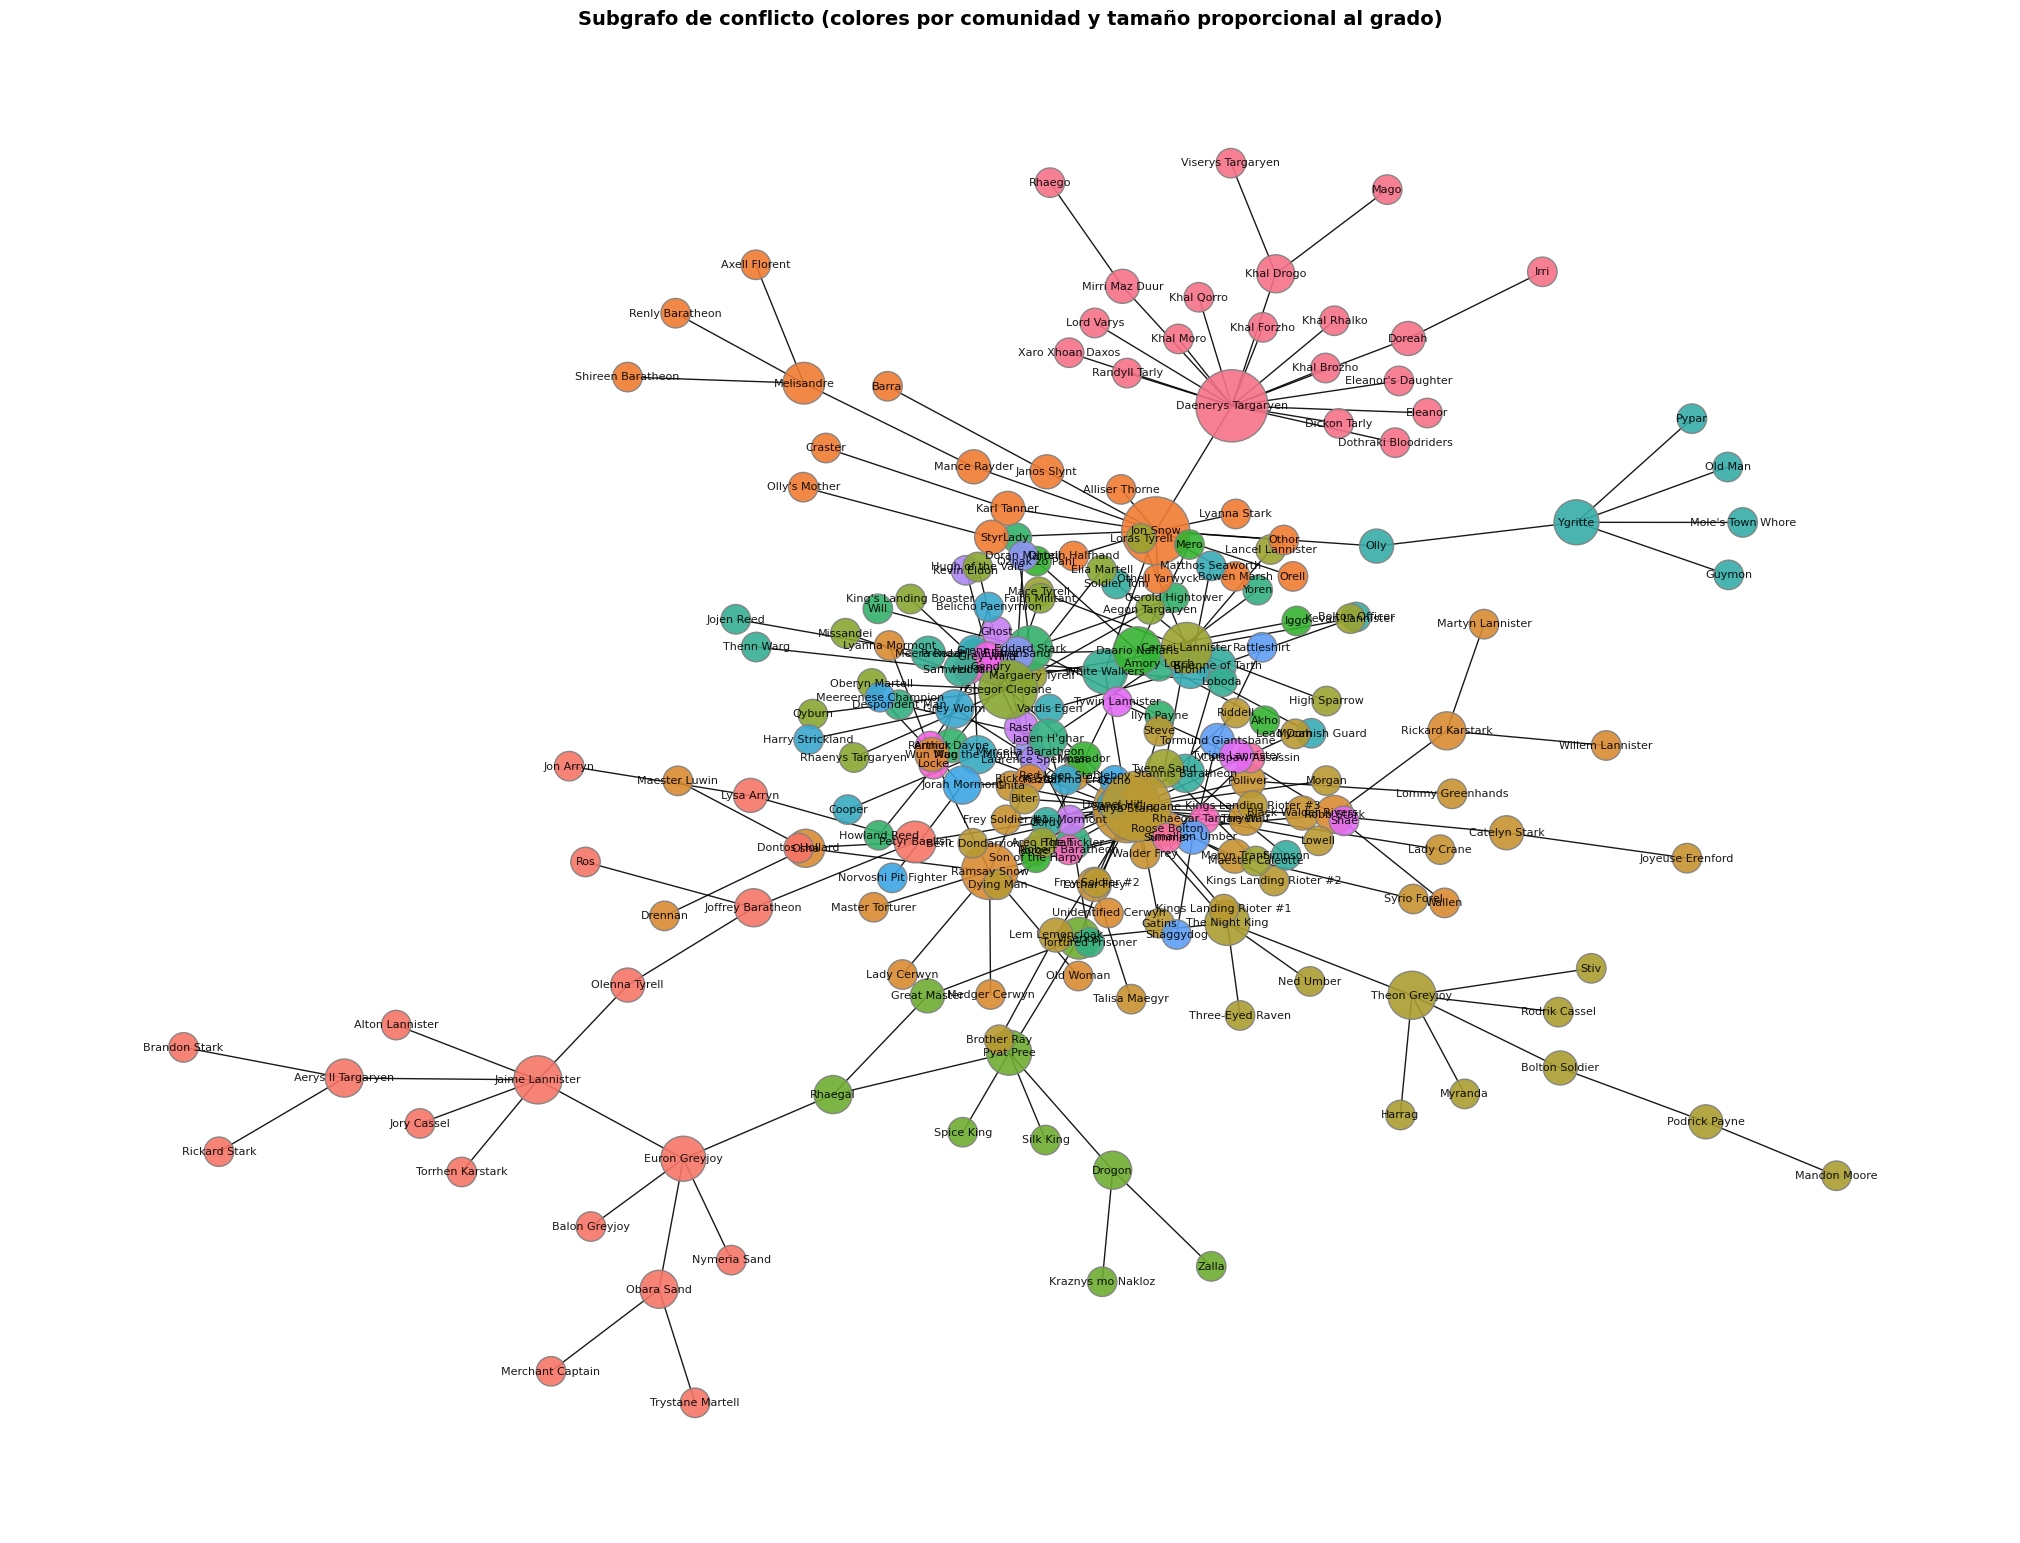

In [354]:
# --- Tamaño de nodos proporcional a su grado ---
node_sizes_fam = [300 + 150 * G_familia.degree(n) for n in G_familia.nodes()]
node_sizes_con = [300 + 150 * G_conflicto.degree(n) for n in G_conflicto.nodes()]

# --- Visualización final con colores y tamaño ---
plt.figure(figsize=(20, 15))
nx.draw(G_familia, pos_familia, node_color=node_colors_fam, node_size=node_sizes_fam, alpha=0.9, edgecolors="gray", with_labels=True, font_size=8)
plt.title("Subgrafo familiar (colores por comunidad y tamaño proporcional al grado)", fontsize=14, fontweight='bold')
plt.axis("off")
plt.show()

plt.figure(figsize=(20, 15))
nx.draw(G_conflicto, pos_conflicto, node_color=node_colors_con, node_size=node_sizes_con, alpha=0.9, edgecolors="gray", with_labels=True, font_size=8)
plt.title("Subgrafo de conflicto (colores por comunidad y tamaño proporcional al grado)", fontsize=14, fontweight='bold')
plt.axis("off")
plt.show()

---- 
**Después de realizar el gráfico, responde brevemente:** 

**• ¿Cuántas comunidades principales has identificado?** 


En total, el algoritmo ha detectado 21 comunidades en el subgrafo familiar y 29 en el de conflicto. Sin embargo, la mayoría son grupos pequeños o secundarios: en ambos casos se observan entre 4 y 6 comunidades principales que concentran la mayor parte de los personajes y relaciones relevantes

**• ¿Coinciden estas comunidades con las casas nobles, alianzas o algún patrón que se pueda reconocer en la serie?** 

Sí. En el subgrafo familiar, las comunidades principales coinciden claramente con las grandes casas nobles (Stark, Lannister, Baratheon, Targaryen y Tyrell).

En el subgrafo de conflicto, las comunidades se organizan más por alianzas y bandos de guerra, reflejando enfrentamientos como los aliados de Daenerys, las fuerzas del Norte o los seguidores de los Lannister, lo que reproduce fielmente la dinámica política de Game of Thrones.

**• ¿Qué decisiones de diseño (colores, tamaño, layout) te han ayudado a mejorar la 
legibilidad del grafo?**

**Subgrafo familiar**

Se ha utilizado una paleta de colores tab20 para diferenciar visualmente las comunidades detectadas, asignando un color único a cada grupo. Esto permite reconocer rápidamente los distintos clústeres familiares sin necesidad de una leyenda adicional.

El tamaño de los nodos se ha ajustado de forma proporcional a su grado (número de relaciones) dentro del subgrafo, de modo que los personajes más conectados destacan de manera inmediata como figuras centrales dentro de su comunidad.

Se ha mantenido un layout de tipo spring_layout en el subgrafo familiar, ya que agrupa de forma natural los nodos con vínculos más fuertes, simulando la cercanía estructural entre miembros de una misma familia.

Los bordes en gris suave y el fondo blanco ayudan a que los colores de las comunidades sean el elemento más visible, evitando sobrecarga visual.

En conjunto, estas decisiones permiten una lectura más intuitiva y limpia del grafo, donde la estructura familiar, las relaciones entre casas y los personajes más influyentes se distinguen fácilmente a simple vista.

**Subgrafo de conflicto**

En el subgrafo de conflictos, las decisiones de diseño se centraron en resaltar la estructura dispersa y las conexiones entre diferentes bandos:

Se mantuvo la paleta tab20 para conservar coherencia visual con el grafo familiar, pero aquí los colores permiten distinguir con mayor claridad los bloques de personajes enfrentados o aliados temporalmente.

Se utilizó el layout kamada_kawai, que distribuye mejor los nodos en redes con menor densidad, separando las comunidades sin romper las conexiones. Este tipo de disposición facilita identificar los distintos focos de conflicto.

El tamaño de los nodos también es proporcional al grado, destacando personajes con múltiples enfrentamientos como Daenerys, Cersei o los líderes de las casas principales.

Los bordes grises y la transparencia ligera de las aristas ayudan a que los nodos de color dominen la visualización, evitando que el exceso de conexiones genere ruido visual.

En conjunto, este diseño enfatiza cómo los conflictos se reparten entre varios centros de poder y muestra de forma clara qué comunidades concentran más violencia o interacción directa, reflejando las alianzas y rivalidades que estructuran la trama de Game of Thrones.

--- 

### <span >**Parte 2: Visualización de grafos con NetworkX**

En esta parte se utilizará la librería Folium para representar información del universo de 
Juego de Tronos sobre un mapa interactivo. El objetivo no es solo mostrar ubicaciones, sino también diseñar una visualización informativa y estética, eligiendo cuidadosamente los colores, los niveles de zoom, los popups y los elementos interactivos.

Al  igual  que  en  los  ejercicios  anteriores,  cada  apartado  deberá  incluir  el  código 
correspondiente y una breve justificación (3–5 líneas) de las decisiones de diseño tomadas: 
selección  del  mapa  base,  estilo  de  las  capas,  escala  de  colores,  tamaño  de  los 
marcadores, tipo de popup, etc.

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Apartado 1: Preparar el mapa base de Juego de Tronos   
</div>

**1. Carga el fichero GeoJSON  y  crea  un  mapa  base  con  Folium que muestre únicamente el terreno del mundo ficticio (sin superponer ningún mapa real de fondo)**


In [351]:
import json

ruta_land = r"./GOT-Map/land.geojson"
with open(ruta_land, encoding="utf-8") as f:
    land_data = json.load(f)

# Inspeccionar algunas coordenadas
for feature in land_data["features"][:3]:
    geom = feature["geometry"]
    print(geom["type"])
    print(geom["coordinates"][0][0][:5])  # primeras 5 coordenadas del primer anillo
    print()


MultiPolygon
[[-15.483936, 39.5395218], [-15.483936, 39.5395218], [-15.483936, 39.6050937], [-15.5912258, 39.6050937], [-15.6439912, 39.6706656]]




**2. Ajusta la visualización para que:**
- El zoom inicial y el centro del mapa se adapten automáticamente al área del GeoJSON.
- Se diferencien claramente las zonas  terrestres  y  marítimas, utilizando colores o capas apropiadas. 
- No se muestren áreas del mapa fuera de los límites del universo de Juego de Tronos (por ejemplo, ajustando límites o aplicando una máscara visual).

**3. Añade un título o anotación descriptiva (por ejemplo, “Mapa de los Siete Reinos”). 
Después de realizar el mapa, responde brevemente las preguntas del final.**

In [352]:
import folium
import json
from IPython.display import HTML, display

# === Cargar GeoJSON ===
ruta_land = r"./GOT-Map/GOT-Map/land.geojson"
with open(ruta_land, encoding='utf-8') as f:
    land_data = json.load(f)

# === Obtener límites ===
def get_bounds(geojson):
    coords = []
    for feature in geojson['features']:
        geometry = feature['geometry']
        if geometry['type'] == 'Polygon':
            coords.extend(geometry['coordinates'][0])
        elif geometry['type'] == 'MultiPolygon':
            for polygon in geometry['coordinates']:
                coords.extend(polygon[0])
    lats = [c[1] for c in coords]
    lngs = [c[0] for c in coords]
    return [[min(lats), min(lngs)], [max(lats), max(lngs)]]

bounds = get_bounds(land_data)
(min_lat, min_lng), (max_lat, max_lng) = bounds

# === Centro y proporciones ===
center_lat = (min_lat + max_lat) / 2
center_lng = (min_lng + max_lng) / 2
lat_span = max_lat - min_lat
lng_span = max_lng - min_lng
aspect_ratio = lng_span / lat_span

# === Crear mapa base limpio ===
m = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=6,
    tiles=None,
    zoom_control=False,
    scrollWheelZoom=False,
    dragging=False,
    control_scale=False
)

# === Capa de tierra ===
folium.GeoJson(
    land_data,
    name='Tierra',
    style_function=lambda feature: {
        'fillColor': '#228B22',
        'color': '#006400',
        'weight': 1,
        'fillOpacity': 0.9
    }
).add_to(m)

# === Ajuste fino manual del encuadre ===
# Primero mostrar todo
m.fit_bounds(bounds)

# Luego recortar: mover un poco hacia abajo y acercar el zoom
center_lat -= 0.38   # baja el encuadre
m.location = [center_lat, center_lng]
m.zoom_start = 6.45  # aumenta ligeramente el zoom

# === CSS limpio tipo póster ===
css = '''
<style>
html, body {
    margin: 0 !important;
    padding: 0 !important;
    overflow: hidden !important;
    background-color: #87CEEB !important;
}
.leaflet-container {
    background: #87CEEB !important;
    border: none !important;
    box-shadow: none !important;
    width: 100vw !important;
    height: 100vh !important;
    margin: 0 auto !important;
}
</style>
'''
m.get_root().header.add_child(folium.Element(css))

# === Mostrar título + mapa ===
display(HTML('''
<h2 style="
    text-align: center;
    font-family: Arial, sans-serif;
    font-weight: bold;
    color: #222;
    margin-bottom: 10px;">
    Mapa de los Siete Reinos
</h2>
'''))

m.save("mapa_siete_reinos.html")
m


FileNotFoundError: [Errno 2] No such file or directory: './GOT-Map/GOT-Map/land.geojson'

**Preguntas:**

**¿Qué capa base (tiles) has utilizado y por qué?**

En la elaboración del mapa se ha optado por **no emplear ninguna capa base convencional**, configurando el parámetro `tiles=None` en el objeto del mapa.  
Esta decisión responde al hecho de que el territorio representado —los Siete Reinos de la saga *Juego de Tronos*— **no corresponde a una localización geográfica real**, por lo que el uso de capas cartográficas como *OpenStreetMap*, *Stamen Terrain* o *CartoDB* habría añadido elementos (calles, nombres de ciudades o fronteras reales) que resultarían incoherentes con el contexto ficticio.  

Al eliminar los tiles, el mapa se presenta como una superficie limpia y neutra, libre de distracciones y completamente centrada en el territorio definido en el archivo `land.geojson`.  
Esto permite al observador concentrarse exclusivamente en la información relevante del universo representado, favoreciendo una **estética más narrativa y conceptual**, similar a la de los mapas de fantasía tradicionales.

Además, al prescindir de una capa base, se obtiene un control total sobre la paleta cromática y la apariencia del mapa, lo que facilita la integración de un fondo personalizado (color del mar) coherente con la composición visual general.



**¿Cómo has definido los colores o estilos para distinguir tierra y mar?**

Los colores se han definido manualmente con el objetivo de conseguir una diferenciación clara y estética entre tierra y mar.  
Para la **tierra**, se ha empleado un tono verde intenso y saturado, con bordes ligeramente más oscuros. Este contraste dentro de la propia masa terrestre aporta sensación de relieve y estructura, al mismo tiempo que mantiene una identidad visual coherente con la representación clásica de la naturaleza.  

Por otro lado, el **mar** se ha representado con un azul cielo suave que abarca toda la extensión visible del mapa. Este color se ha aplicado no solo como un rectángulo que cubre el área geográfica, sino también como color de fondo de la página, eliminando cualquier borde gris que pudiera aparecer en el entorno del visor.  
La elección de un azul claro, en lugar de un tono marino oscuro, permite equilibrar la luminosidad general del mapa y destacar el contorno verde de la tierra, garantizando legibilidad y armonía visual.

La paleta empleada refuerza así la **lectura visual inmediata del territorio**, aportando una estética equilibrada, con contraste suficiente para diferenciar los elementos principales sin introducir ruido visual ni perder naturalidad.





**¿Cómo has implementado la función para obtener los valores para ajustar el zoom y centro del mapa para mejorar la visualización?**

Para mejorar la visualización del territorio, se implementó una función capaz de calcular automáticamente los **límites espaciales** del archivo `land.geojson`. A partir de las coordenadas mínimas y máximas de latitud y longitud, se determinaron los valores necesarios para **centrar el mapa y ajustar el nivel de zoom de forma precisa**.  

Este enfoque garantiza que el mapa muestre toda la extensión del continente sin recortes ni márgenes excesivos.  
Una vez obtenidos los límites y el punto central, se realizó un **ajuste fino manual** para equilibrar la composición: el centro se desplazó ligeramente hacia el sur, de modo que el título no se superpusiera al área de tierra y la visualización quedara más proporcionada.  
Del mismo modo, el nivel de zoom se incrementó levemente respecto al valor automático, buscando un equilibrio entre visibilidad de detalle y amplitud general del territorio.

Estos ajustes, tanto automáticos como manuales, responden a un criterio de **optimización visual y narrativa**: el mapa debía ocupar el espacio de visualización de forma armónica, sin recortar elementos importantes ni dejar áreas vacías.  
El resultado final es un mapa centrado, proporcionado y coherente, que prioriza la comprensión geográfica del territorio representado y mantiene una composición estética adecuada para el contexto de visualización de datos.


**Conclusión:**

En conjunto, las decisiones adoptadas —ausencia de tiles, elección de colores naturales y cálculo preciso del centro y zoom— buscan crear un mapa **limpio, legible y visualmente equilibrado**, donde cada elemento cumple una función concreta en la representación y comunicación del territorio ficticio de los Siete Reinos.

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Apartado 2: Mostrar la importancia de cada ubicación  
</div>

A partir del mapa base del apartado anterior, representa la frecuencia de aparición de las 
localizaciones en la serie.

**1. Utiliza  los  datos  del  dataset  de  episodios  (episodes.json) para contar en cuántos 
episodios aparece cada localización.**



**2. Sobre el mapa, añade marcas circulares en cada ubicación:**
- **El diámetro del círculo deberá depender del número total de episodios en los que aparece esa localización.**
- **Define una paleta de colores o escala que refuerce la interpretación (por ejemplo, tonos más intensos para lugares con mayor presencia).**

**3. Incluye popups y/o tooltips informativos con al menos:**
- **Nombre de la localización.**
- **Número de episodios en los que aparece.**
- **Otros datos que consideres interesantes mostrar.**

**4. Ajusta  el  mapa  para  que  las  marcas  sean  legibles,  evitando  solapamientos o tamaños excesivos. Después de realizar el mapa, responde brevemente las preguntas del final.**

In [ ]:
# === Apartado 2: Localizaciones de los Siete Reinos (versión mejorada con colores diferenciados) ===

import folium
import json
from IPython.display import HTML, display

# === Cargar GeoJSON ===
ruta_land = r"./GOT-Map/GOT-Map/land.geojson"
ruta_places = r"./GOT-Map/GOT-Map/places.geojson"

with open(ruta_land, encoding='utf-8') as f:
    land_data = json.load(f)

with open(ruta_places, encoding='utf-8') as f:
    places_data = json.load(f)

# === Obtener límites ===
def get_bounds(geojson):
    coords = []
    for feature in geojson['features']:
        geometry = feature['geometry']
        if geometry['type'] == 'Polygon':
            coords.extend(geometry['coordinates'][0])
        elif geometry['type'] == 'MultiPolygon':
            for polygon in geometry['coordinates']:
                coords.extend(polygon[0])
    lats = [c[1] for c in coords]
    lngs = [c[0] for c in coords]
    return [[min(lats), min(lngs)], [max(lats), max(lngs)]]

bounds = get_bounds(land_data)
(min_lat, min_lng), (max_lat, max_lng) = bounds

# === Calcular centro ===
center_lat = (min_lat + max_lat) / 2
center_lng = (min_lng + max_lng) / 2

# === Crear mapa base limpio ===
m = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=6,
    tiles=None,
    zoom_control=False,
    scrollWheelZoom=False,
    dragging=False,
    control_scale=False
)

# === Capa de tierra ===
folium.GeoJson(
    land_data,
    name='Tierra',
    style_function=lambda feature: {
        'fillColor': '#228B22',
        'color': '#006400',
        'weight': 1,
        'fillOpacity': 0.9
    }
).add_to(m)

# === Ajuste del encuadre ===
m.fit_bounds(bounds)
center_lat -= 0.38
m.location = [center_lat, center_lng]
m.zoom_start = 6.45

# === Añadir puntos con paleta perceptualmente diferenciable ===
for i, feature in enumerate(places_data["features"]):
    geom = feature["geometry"]
    props = feature["properties"]

    lon, lat = geom["coordinates"]
    name = props.get("name", "Lugar desconocido")
    importance = props.get("importance", None)

    # Clasificación automática o jerárquica
    if importance is None:
        if i % 15 == 0:
            color = "#E74C3C"   # rojo fuerte (capitales)
            radius = 6
        elif i % 5 == 0:
            color = "#FF7F0E"   # naranja brillante (ciudades principales)
            radius = 5
        else:
            color = "#FFD700"   # amarillo oro (localidades menores)
            radius = 4
    else:
        val = str(importance).lower()
        if val in ["capital", "main", "principal"]:
            color = "#E74C3C"
            radius = 6
        elif val in ["medium", "secondary", "secundary"]:
            color = "#FF7F0E"
            radius = 5
        else:
            color = "#FFD700"
            radius = 4

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        popup=folium.Popup(f"<b>{name}</b>", max_width=200)
    ).add_to(m)

# === CSS tipo póster ===
css = '''
<style>
html, body {
    margin: 0 !important;
    padding: 0 !important;
    overflow: hidden !important;
    background-color: #87CEEB !important;
}
.leaflet-container {
    background: #87CEEB !important;
    border: none !important;
    box-shadow: none !important;
    width: 100vw !important;
    height: 100vh !important;
    margin: 0 auto !important;
}
</style>
'''
m.get_root().header.add_child(folium.Element(css))

# === Mostrar título + mapa ===
display(HTML('''
<h2 style="
    text-align: center;
    font-family: Arial, sans-serif;
    font-weight: bold;
    color: #222;
    margin-bottom: 10px;">
    Localizaciones de los Siete Reinos
</h2>
'''))

m.save("localizaciones_siete_reinos.html")
m


**Preguntas:**

- ¿Qué criterio has seguido para definir el tamaño y color de los círculos? 



- ¿Qué información has decidido incluir en los popups y por qué? 



- ¿Qué tipo de capa o fondo permite visualizar mejor la distribución de los puntos?



**Respuestas:**

**1. Criterio seguido para definir el tamaño y color de los círculos:**

El diseño cromático y dimensional de los marcadores se ha planteado con el objetivo de comunicar la **importancia jerárquica de las localizaciones** dentro del territorio de los Siete Reinos, facilitando su lectura visual sin sobrecargar el mapa.

Se ha utilizado una paleta perceptualmente diferenciada formada por tres colores cálidos:
- **Rojo intenso (`#E74C3C`)** para los puntos de mayor relevancia, como capitales o asentamientos principales. Este tono destaca fuertemente sobre el verde y el azul del fondo, dirigiendo la atención hacia los centros de poder.
- **Naranja brillante (`#FF7F0E`)** para las ciudades intermedias o de relevancia media. Es un color de transición que conserva el contraste con el entorno, pero sin competir visualmente con las capitales.
- **Amarillo dorado (`#FFD700`)** para los asentamientos menores. Este color ofrece buena visibilidad sin saturar la composición, manteniendo un equilibrio general.

Los tamaños de los círculos (6 px, 5 px y 4 px respectivamente) refuerzan visualmente esta jerarquía y garantizan que los puntos no se solapen excesivamente en áreas densas.  
El uso de colores cálidos sobre un entorno frío (mar azul y tierra verde) aumenta el contraste y la legibilidad, respetando los principios de **armonía cromática y jerarquía visual** en la representación cartográfica.


**2. Información incluida en los popups:**

Cada marcador incluye un **popup con el nombre de la localización**, lo que permite identificar los puntos sin añadir texto directamente sobre el mapa.  
Esta decisión sigue un criterio de **claridad visual y economía informativa**: el mapa se centra en mostrar la distribución espacial de los asentamientos, mientras que la información textual se accede bajo demanda.  

De esta forma, el usuario puede explorar el territorio interactivamente sin comprometer la legibilidad global ni distraer la atención del patrón geográfico general.


**3. Tipo de capa o fondo utilizado para la visualización:**

Se ha mantenido un **fondo neutro sin tiles reales** (`tiles=None`), empleando una base de color azul uniforme para el mar y verde intenso para la tierra.  
Esta configuración evita interferencias visuales con la capa de puntos —como etiquetas, carreteras o elementos cartográficos ajenos al universo ficticio— y proporciona un escenario visualmente coherente con la ambientación de *Juego de Tronos*.  

El contraste entre la superficie terrestre y marina ayuda a contextualizar los puntos sin añadir ruido visual, mientras que la ausencia de tiles refuerza la estética minimalista y centrada en la información esencial.


**4. Otros aspectos de diseño:**

El título se ubica **fuera del área del mapa**, siguiendo un estilo de composición tipo póster que mantiene la limpieza visual y la coherencia con el mapa base del apartado 1.  
Se han conservado la **proporción y el encuadre** del mapa original, desplazando ligeramente el centro hacia el sur para equilibrar la composición y dejar espacio al título.

En conjunto, las decisiones cromáticas, jerárquicas y compositivas garantizan una visualización **clara, equilibrada y coherente**, que permite al observador identificar fácilmente los patrones de distribución y los focos de importancia dentro del territorio de los Siete Reinos.

<div style="background-color:#f5f3ff; color:#6a0dad; padding:10px; border-radius:5px;">
Apartado 3: Visualizar la ruta de lugares en un episodio
</div>

En este apartado se representará la ruta  de  lugares  visitados  en un  episodio  concreto, 
utilizando líneas y marcadores sobre el mapa base. 

**1. Selecciona  un  episodio  concreto  del  dataset  (episodes.json)  y  extrae  las localizaciones que aparecen en sus escenas, en el orden en que se muestran.**

**2. Representa sobre el mapa:** 
- **Marcadores  en  cada  lugar  visitado,  numerados  o  etiquetados  según  el orden de aparición.**
- **Una línea que conecte los lugares en secuencia, representando el recorrido del episodio.**

**3. Configura popups y tooltips informativos tanto para los nodos (lugares) como para las aristas (trayectos), incluyendo:**
- **Nombre del lugar.**
- **Nombre de sublugares que aparecen.**
- **Número de veces que el lugar aparece en el episodio.**

**4. Permite seleccionar el episodio a representar mediante una variable o parámetro del código.**

**5. Ajusta aspectos visuales (colores, grosor, tamaño de nodos) para facilitar la lectura del recorrido.**

In [ ]:

# === Archivos base ===
ruta_land = r"./GOT-Map/GOT-Map/land.geojson"
ruta_places = r"./GOT-Map/GOT-Map/places.geojson"
ruta_episodes = r"./game_of_thrones/data/episodes.json"

# === Cargar datos ===
with open(ruta_land, encoding='utf-8') as f:
    land_data = json.load(f)

with open(ruta_places, encoding='utf-8') as f:
    places_data = json.load(f)

with open(ruta_episodes, encoding='utf-8') as f:
    raw = json.load(f)
    # Si el JSON tiene una clave principal ("episodes"), accedemos dentro
    if isinstance(raw, dict) and "episodes" in raw:
        episodes_data = raw["episodes"]
    elif isinstance(raw, list):
        episodes_data = raw
    else:
        raise ValueError("Estructura de episodes.json no reconocida")

# === Seleccionar un episodio concreto ===
episodio_id = 3  # ← Cambia este número para elegir otro episodio
episodio = next((ep for ep in episodes_data if ep.get("episodeNum") == episodio_id), None)

# === Extraer lugares en orden de aparición ===
locations_sequence = []
if episodio and "scenes" in episodio:
    for scene in episodio["scenes"]:
        loc = scene.get("location")
        if loc:
            locations_sequence.append(loc)

# === Contar repeticiones ===
freq = Counter(locations_sequence)

# === Vincular coordenadas desde places.geojson ===
place_coords = {}
for feature in places_data["features"]:
    props = feature["properties"]
    geom = feature["geometry"]
    name = props.get("name")
    lon, lat = geom["coordinates"]
    place_coords[name] = (lat, lon)

# === Filtrar lugares del episodio ===
episode_coords = [(loc, place_coords[loc]) for loc in locations_sequence if loc in place_coords]

# === Obtener límites del mapa ===
def get_bounds(geojson):
    coords = []
    for feature in geojson["features"]:
        geometry = feature["geometry"]
        if geometry["type"] == "Polygon":
            coords.extend(geometry["coordinates"][0])
        elif geometry["type"] == "MultiPolygon":
            for polygon in geometry["coordinates"]:
                coords.extend(polygon[0])
    lats = [c[1] for c in coords]
    lngs = [c[0] for c in coords]
    return [[min(lats), min(lngs)], [max(lats), max(lngs)]]

bounds = get_bounds(land_data)
(min_lat, min_lng), (max_lat, max_lng) = bounds
center_lat = (min_lat + max_lat) / 2
center_lng = (min_lng + max_lng) / 2

# === Crear mapa base coherente con los anteriores ===
m = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=6.45,
    tiles=None,
    zoom_control=True,
    scrollWheelZoom=False,
    control_scale=True
)

# === Fondo marino ===
folium.Rectangle(
    bounds=[[min_lat - 5, min_lng - 5], [max_lat + 5, max_lng + 5]],
    color="#87CEEB",
    fill=True,
    fill_color="#87CEEB",
    fill_opacity=1
).add_to(m)

# === Capa de tierra ===
folium.GeoJson(
    land_data,
    name="Tierra",
    style_function=lambda feature: {
        "fillColor": "#228B22",
        "color": "#006400",
        "weight": 1,
        "fillOpacity": 0.9
    }
).add_to(m)

# === Capa de la ruta del episodio ===
ruta_layer = folium.FeatureGroup(name=f"Ruta episodio {episodio_id}", show=True)

coords = []
for idx, (name, (lat, lon)) in enumerate(episode_coords, start=1):
    coords.append([lat, lon])

    popup_html = f"""
    <b>{name}</b><br>
    Apariciones: {freq[name]}<br>
    Orden: {idx}
    """
    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        color="#E74C3C" if idx == 1 else "#FF7F0E" if idx == len(episode_coords) else "#FFD700",
        fill=True,
        fill_color="#FFD700",
        fill_opacity=0.9,
        popup=popup_html,
        tooltip=f"{idx}. {name}"
    ).add_to(ruta_layer)

# === Línea de conexión ===
if len(coords) > 1:
    folium.PolyLine(
        coords,
        color="#8B0000",
        weight=3,
        opacity=0.8,
        tooltip=f"Recorrido del episodio {episodio_id}"
    ).add_to(ruta_layer)

ruta_layer.add_to(m)

# === Control de capas ===
folium.LayerControl(collapsed=False).add_to(m)

# === CSS y título ===
css = '''
<style>
html, body {
    margin: 0 !important;
    padding: 0 !important;
    overflow: hidden !important;
    background-color: #87CEEB !important;
}
.leaflet-container {
    background: #87CEEB !important;
    width: 100vw !important;
    height: 100vh !important;
    margin: 0 auto !important;
}
</style>
'''
m.get_root().header.add_child(folium.Element(css))

titulo = (
    episodio.get("episodeTitle")
    or episodio.get("title")
    or f"Episodio {episodio_id}"
) if episodio else f"Episodio {episodio_id}"

display(HTML(f'''
<h2 style="
    text-align: center;
    font-family: Arial, sans-serif;
    font-weight: bold;
    color: #222;
    margin-bottom: 10px;">
    Ruta de lugares visitados en el episodio: {titulo}
</h2>
'''))

# === Guardar ===
m.save(f"mapa_ruta_episodio_{episodio_id}.html")
m


**Justificación de diseño:**

**1. Selección del episodio y estructura de datos:**

En este apartado se ha representado la secuencia de lugares visitados a lo largo de un episodio concreto de *Juego de Tronos*, utilizando la información contenida en el fichero `episodes.json`.  
Para ello, se ha seleccionado un episodio mediante una variable (`episodio_id`), lo que permite modificar fácilmente el número de episodio y generar automáticamente la ruta correspondiente sin cambiar el resto del código.  

La extracción de los datos se realiza identificando el episodio según su número (`episodeNum`) y obteniendo la secuencia de localizaciones que aparecen en sus escenas.  
Posteriormente, esta información se cruza con el archivo `places.geojson`, que proporciona las coordenadas geográficas de cada lugar, permitiendo posicionarlos correctamente sobre el mapa.

**2. Representación de la ruta y los lugares:**

Cada punto en el mapa corresponde a un lugar visitado durante el episodio.  
Estos puntos se representan como **marcadores circulares**, cuyo orden en la narrativa se respeta mediante una **línea poligonal (PolyLine)** que conecta las localizaciones en la secuencia exacta en que aparecen.  
Esta línea actúa como una guía visual del recorrido del episodio, transmitiendo la progresión espacial de la historia.  

Además, el tamaño y el color de los marcadores han sido seleccionados para resaltar la jerarquía narrativa:
- El primer lugar del episodio se muestra con un tono anaranjado más intenso.
- Los lugares intermedios utilizan un color dorado (`#FFD700`), que mantiene la coherencia cromática con apartados anteriores.
- La línea de conexión se representa en rojo oscuro (`#8B0000`), creando contraste con el fondo azul del mar y facilitando la lectura del trazado.


**3. Información adicional en popups y tooltips:**

Para mejorar la comprensión del recorrido, cada marcador incorpora un *popup* informativo y un *tooltip* interactivo.  
Estos elementos muestran:
- **El nombre del lugar**,  
- **El orden de aparición** dentro del episodio,  
- Y **el número de veces** que el lugar aparece en las escenas de dicho episodio.

Esta información permite no solo identificar visualmente los puntos, sino también obtener detalles narrativos y cuantitativos sobre su relevancia.  
De este modo, el mapa funciona tanto como una representación espacial como una herramienta exploratoria del guion del episodio.


**4. Coherencia visual y diseño del mapa:**

El estilo general del mapa mantiene la estética de los apartados anteriores para conservar la coherencia visual del conjunto:
- Fondo marino azul claro (`#87CEEB`) para destacar las áreas terrestres.  
- Capa de tierra en verde oscuro (`#228B22`) con borde (`#006400`) para definir el contorno del territorio.  
- Ruta superpuesta en tonos cálidos que contrastan con el entorno.  

El título del mapa se sitúa fuera del área geográfica, en la parte superior, utilizando la tipografía y jerarquía visual establecida en los apartados previos.  
Además, se ha añadido un **control de capas** que permite activar o desactivar la visualización de la ruta o del mapa base, aportando flexibilidad y claridad en el análisis.


**5. Conclusión:**

El resultado final combina la narrativa espacial de *Juego de Tronos* con una representación geográfica clara y estéticamente coherente.  
La visualización permite comprender, de un solo vistazo, **la secuencia y conexión de los lugares visitados durante el episodio**, aportando una lectura simultáneamente narrativa y geográfica.  
Con este apartado, se completa un mapa interactivo que integra tanto la estructura del mundo ficticio como el desarrollo de su trama, cumpliendo plenamente los requisitos del ejercicio.
